# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 11     |  |
| :-------------|:-------------|
| Hugo Rutten | 6541593 |
| Yael Jawahierkhan | 6444504 |
| Matteo Leonardi | 6391494 |

In [2]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Yael Jawahierkhan','Matteo Leonardi']

## Opdracht 1: Planning.

| Planning Groep: 11     |Tijdstip / Tijdspanne  |
|---|---|
| Kalibreren van de sensor af | 11:30 |
| Testen meetopstelling | 12:00 |
| Algoritme iteratie 0 af | 15:00 |
| Iteraties maken | 16:30 |
| Alles testen en opruimen | 16:30-17:30 |
| groep aanwezig 1| 10:45 |
| Pauze 1| 12:45-13:45 |


## Opdracht 2: Import libs.

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [11]

<img src="KalibratieOpstelling.jpeg" width="400">

a= 0.03440668755754128
b =  0.3237959096074584


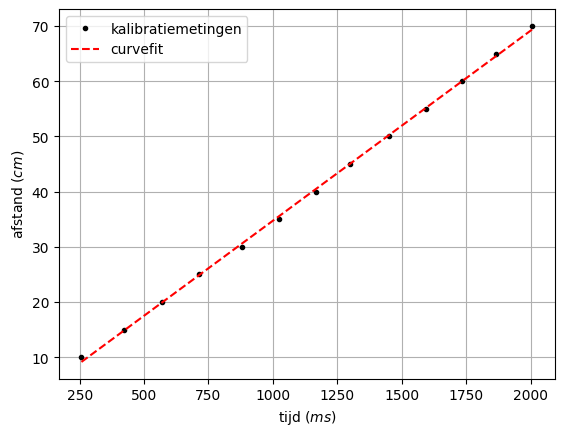

In [4]:
# verwerk hier jullie kalibratiemetingen
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


tijden = np.array([257,424,569,715,881,1023,1167,1301,1450,1595,1735,1867,2007]) #ms
afstanden = np.array([10.0,15.0,20.0, 25.0,30.0,35.0,40.0,45.0,50.0,55.0,60.0,65.0,70.0]) #cm

x_test = np.linspace(np.min(tijden),np.max(tijden))

def fit(x,a,b):
    return a*x+b

val, cov = curve_fit(fit,tijden,afstanden)

print('a=', val[0])
print( 'b = ', val[1])


plt.figure()
plt.plot(tijden,afstanden,'k.',label='kalibratiemetingen')
plt.plot(x_test,fit(x_test,*val),'r--',label='curvefit')
plt.ylabel('afstand $(cm)$')
plt.xlabel('tijd $(ms)$')
plt.grid()
plt.legend()
plt.show()


## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  40   0  30  44.47
1   0  30   0  20  45.52
2  40   0  30   0  47.95
3  30   0  20   0  47.58


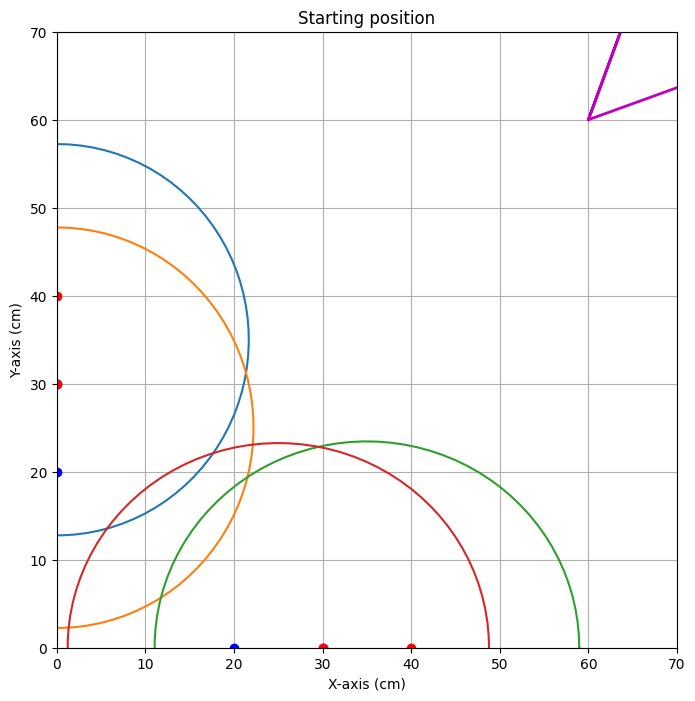


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=95.575
end iteration 2 with average mismatch=87.193


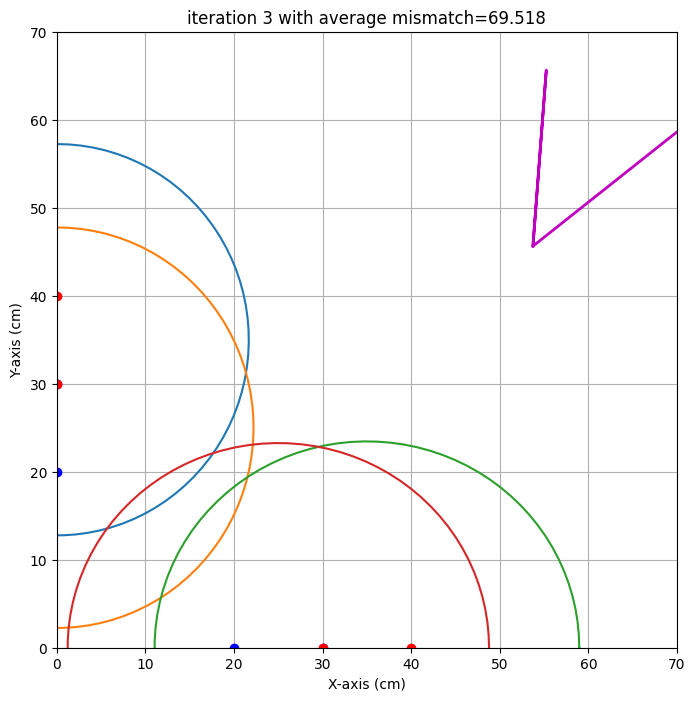

end iteration 3 with average mismatch=69.518


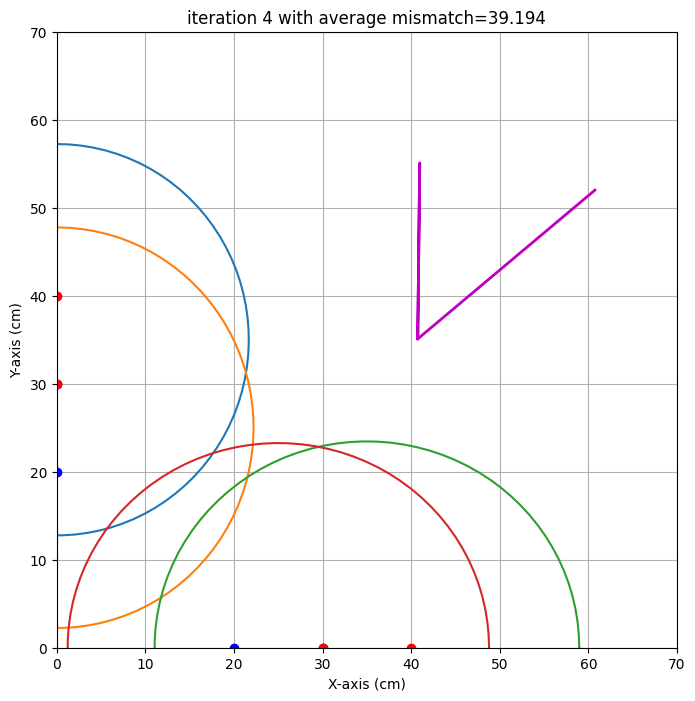

end iteration 4 with average mismatch=39.194


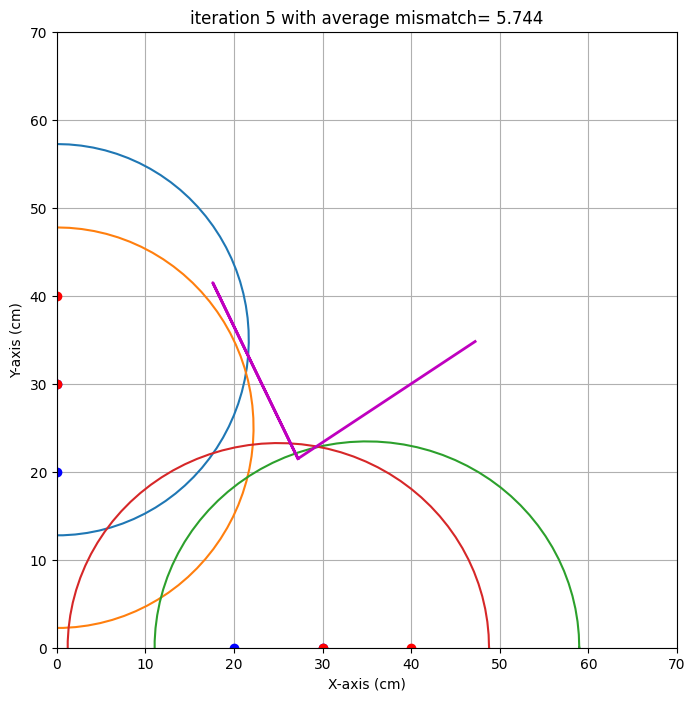

end iteration 5 with average mismatch= 5.744


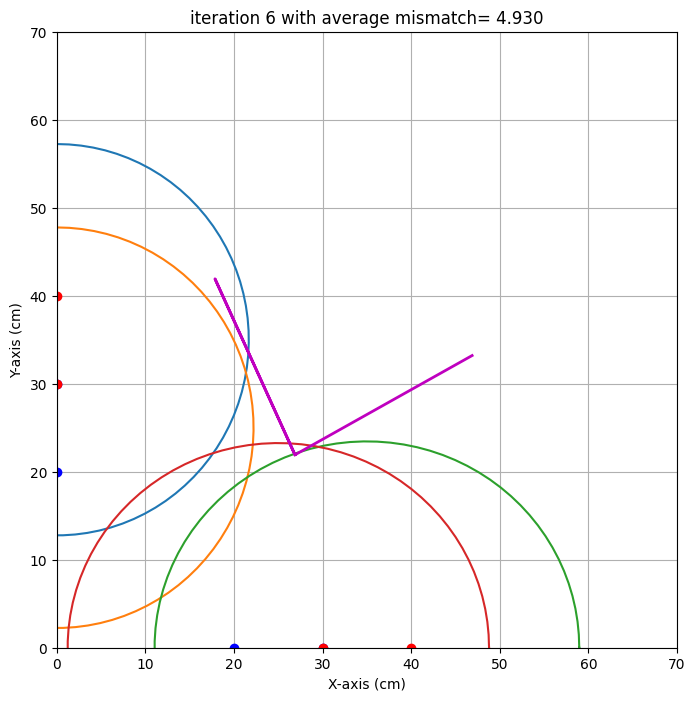

end iteration 6 with average mismatch= 4.930


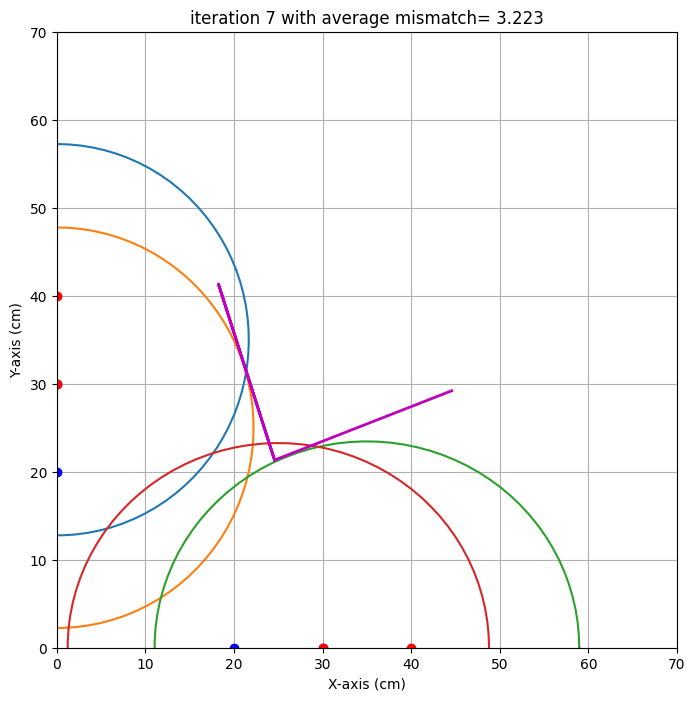

end iteration 7 with average mismatch= 3.223


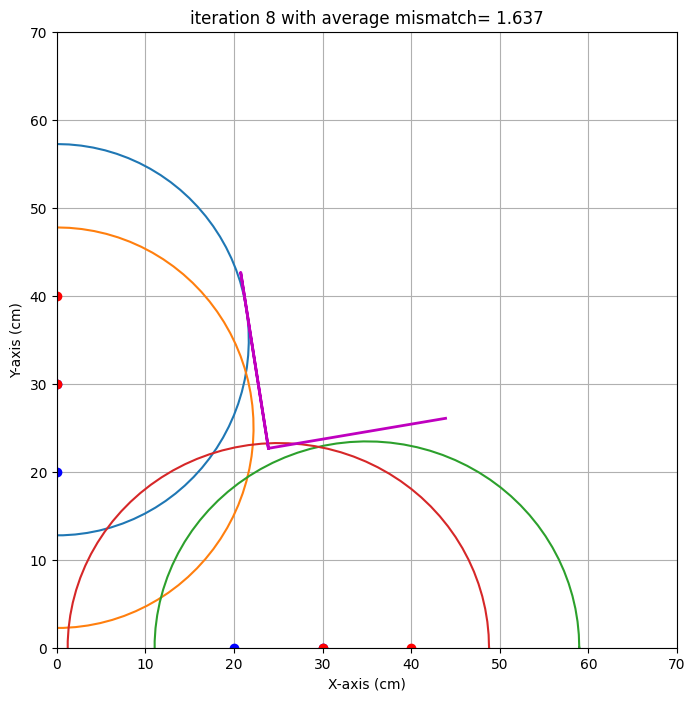

end iteration 8 with average mismatch= 1.637


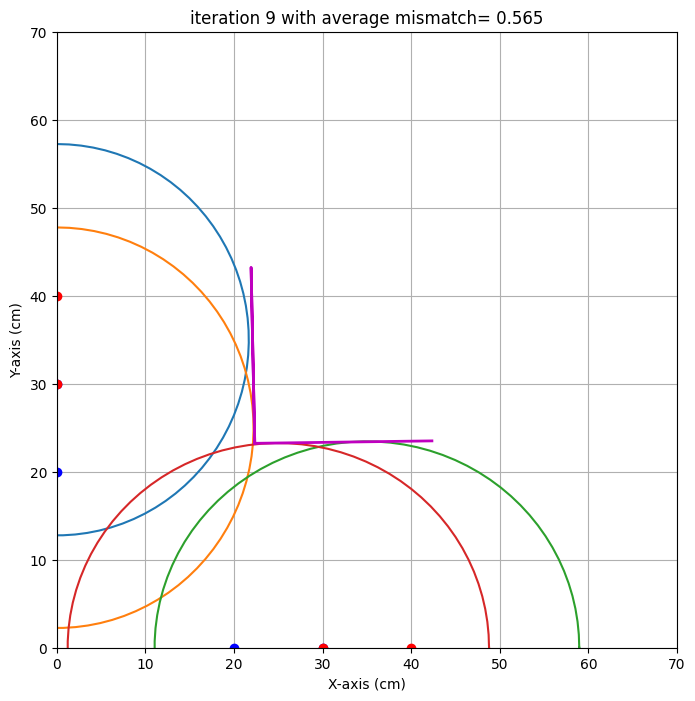

end iteration 9 with average mismatch= 0.565


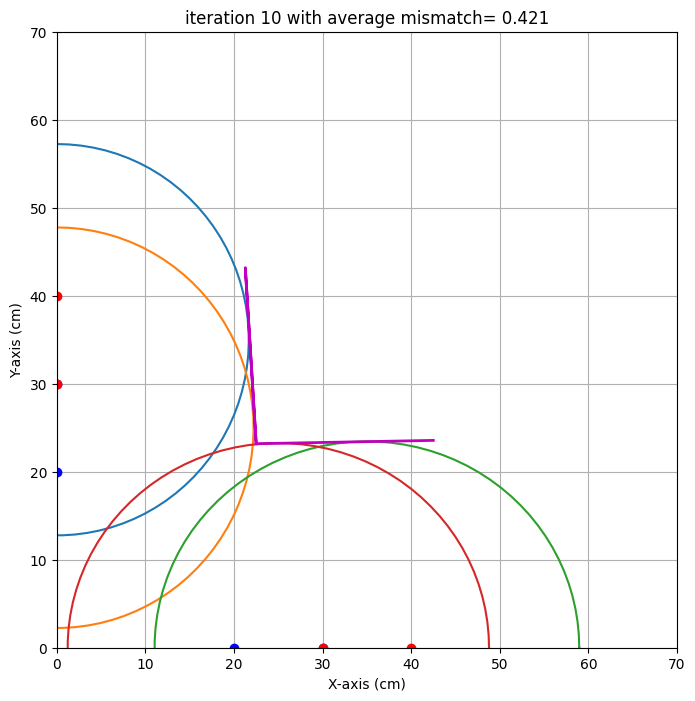

end iteration 10 with average mismatch= 0.421


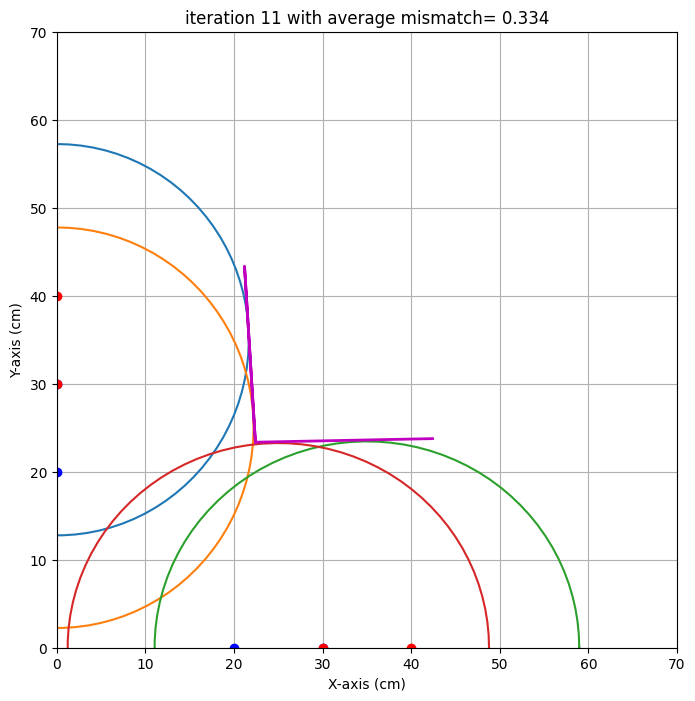

end iteration 11 with average mismatch= 0.334
end iteration 12 with average mismatch= 0.307


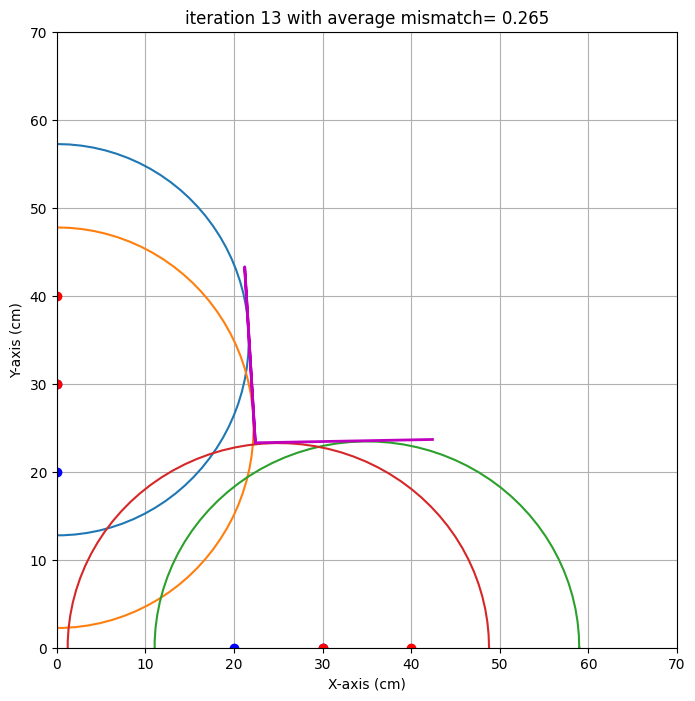

end iteration 13 with average mismatch= 0.265


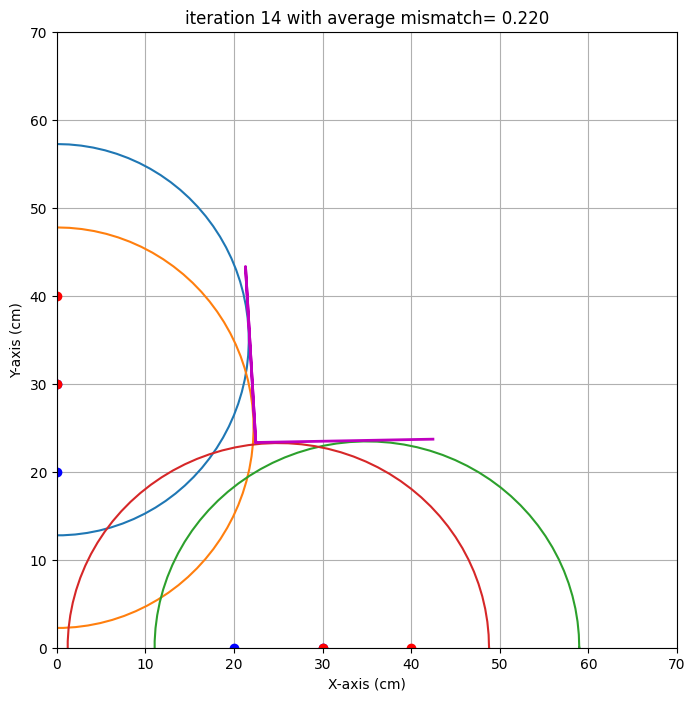

end iteration 14 with average mismatch= 0.220


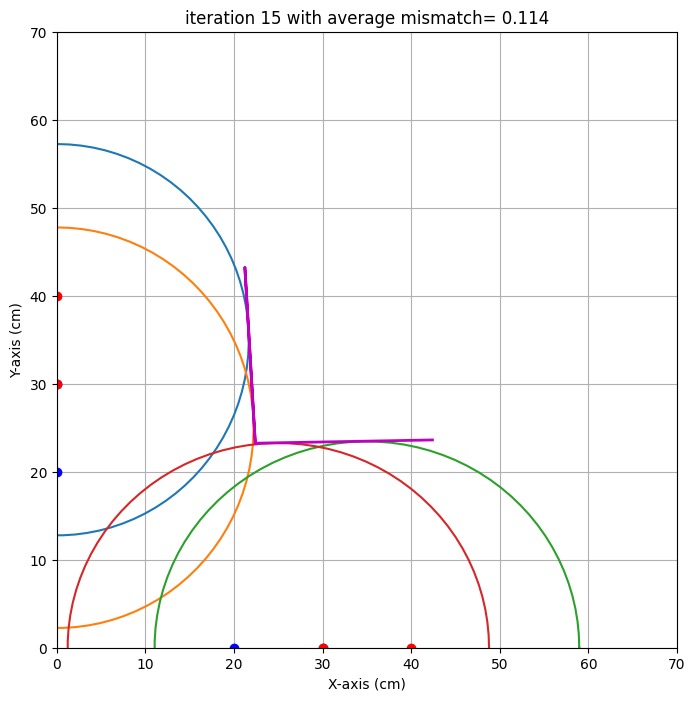

end iteration 15 with average mismatch= 0.114
end iteration 16 with average mismatch= 0.110
end iteration 17 with average mismatch= 0.109
end iteration 18 with average mismatch= 0.109
end iteration 19 with average mismatch= 0.109
end iteration 20 with average mismatch= 0.109
end iteration 21 with average mismatch= 0.108
end iteration 22 with average mismatch= 0.108
end iteration 23 with average mismatch= 0.108
end iteration 24 with average mismatch= 0.108
end iteration 25 with average mismatch= 0.108
end iteration 26 with average mismatch= 0.108
end iteration 27 with average mismatch= 0.108
end iteration 28 with average mismatch= 0.108
end iteration 29 with average mismatch= 0.108
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.108
###############################################################################
end of iteration  30
Best

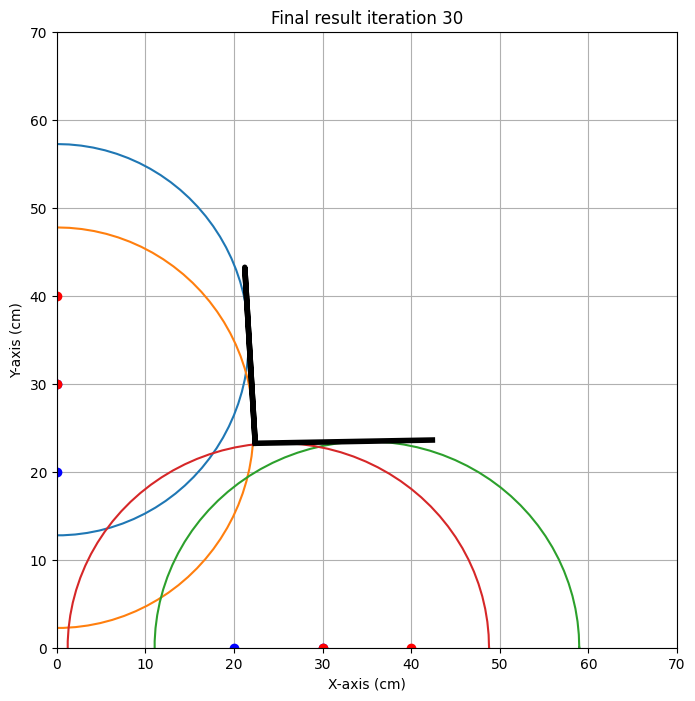

In [5]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,44.47],
    [0,30,0,20,45.52],
    #[0,10,0,20,193.37],
    [40,0,30,0,47.95],
    [30,0,20,0,47.58],
    #[10,0,20,0,190.56],
    #[10,0,0,10,191.41]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [6]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 22.4 cm met een standaardafwijking van 0.0 cm 
y0: 23.2 cm met een standaardafwijking van 0.0 cm 
alpha: 1.1 graden met een standaardafwijking van 0.0 graad 
beta: -3.4 graden met een standaardafwijking van 0.0 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Hugo Rutten]

Voeg een foto in van het algoritme van het eerste groepslid

<img src="SchemaHugo.jpeg" width="400">

#### algoritme [Yael Jawahierkhan]

Voeg een foto in van het algoritme van het tweede groepslid

<img src="SchemaYael.jpeg" width="400">

#### algoritme [Matteo Leonardi]

Voeg een foto in van het algoritme van het derde groepslid

<img src="SchemaMatteo.jpeg" width="400">

In [7]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [8]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 24,   
           'y0': 31,
           'alpha': 25,  
           'beta': 10,  
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Yael Jawahierkhan' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
  [62.4,0,52.5,0,83.5],
    [0,62.5,0,52.5,65.2],
    #[0,70,0,60,200],
    #[70,0,60,0,200],

    ]),
       'Matteo Leonardi' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
  [70,0,50,0,87.8],
    [60,0,40,0,79.6],
    [60,0,50,0,81.5],
    [0,70,0,50,67.9],  
    [0,60,0,40,63.6],
    [0,60,0,50,63.2],
    ])}

## Opdracht 7: Evaluatie.

Yael Jawahierkhan
Running the imaging algorithm with the following data:
     xs    ys    xr    yr     R
0  62.4   0.0  52.5   0.0  83.5
1   0.0  62.5   0.0  52.5  65.2


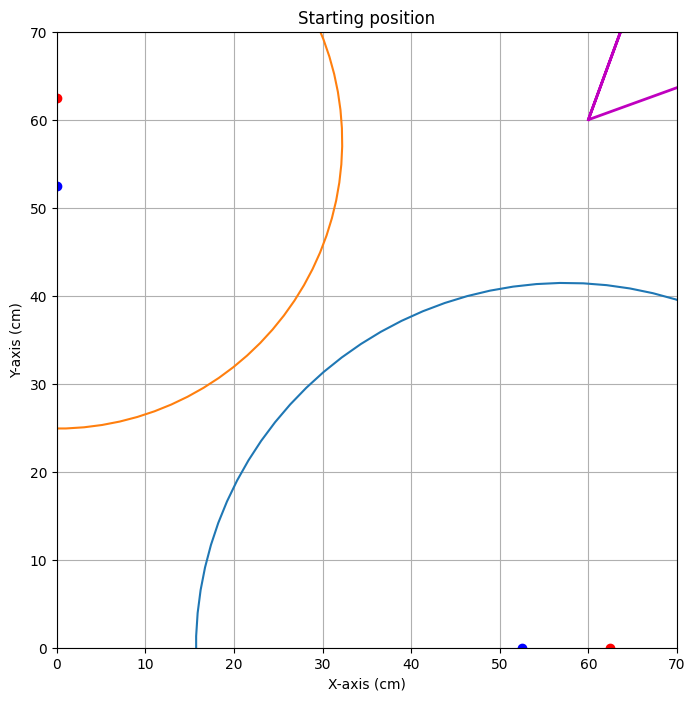


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=51.706


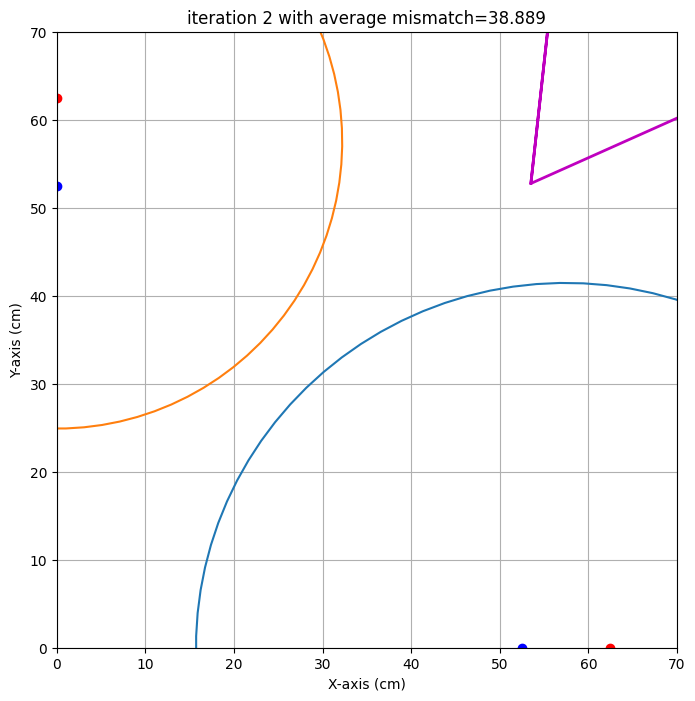

end iteration 2 with average mismatch=38.889


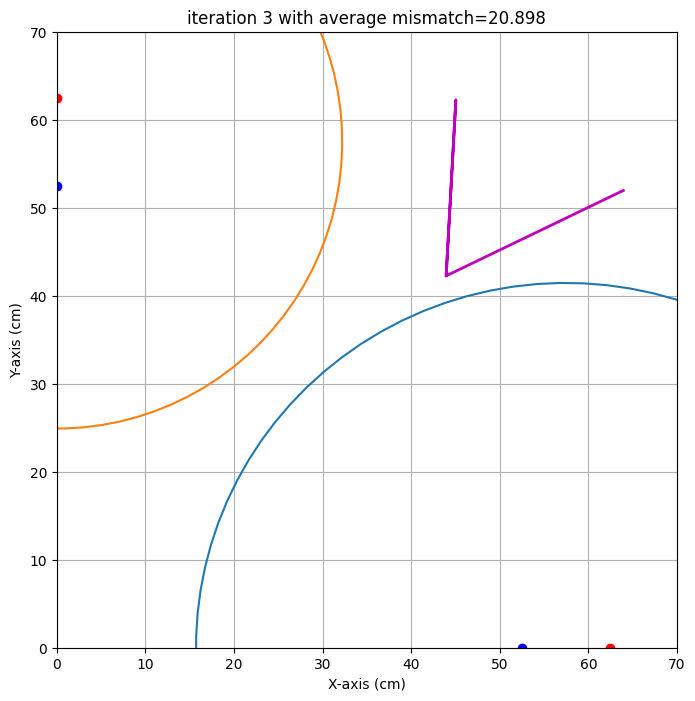

end iteration 3 with average mismatch=20.898


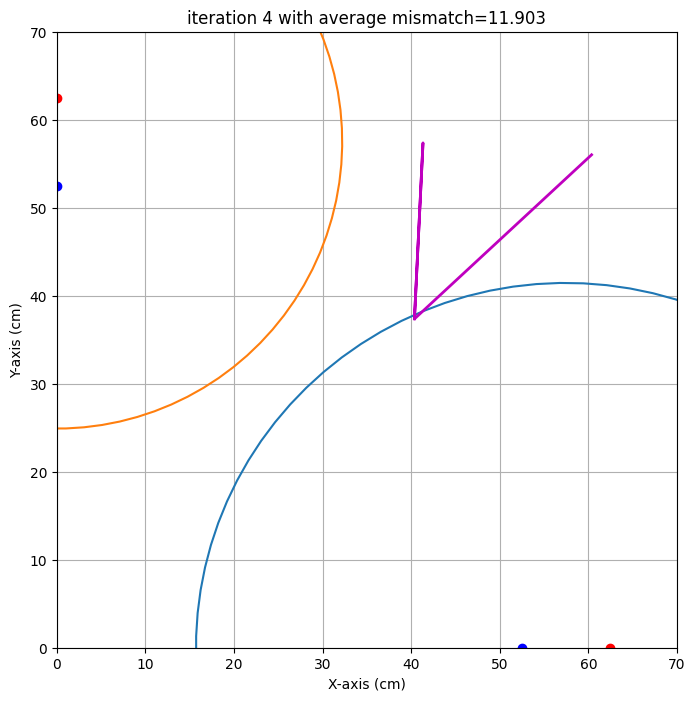

end iteration 4 with average mismatch=11.903


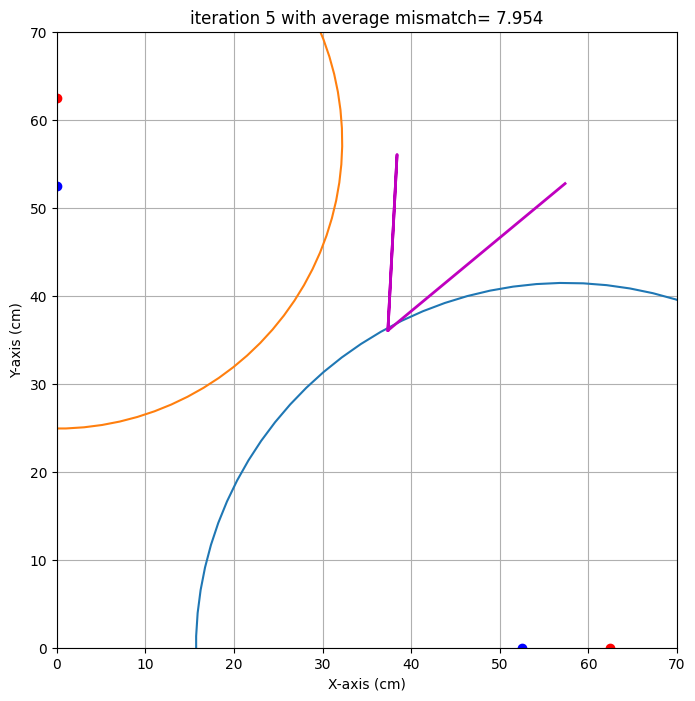

end iteration 5 with average mismatch= 7.954


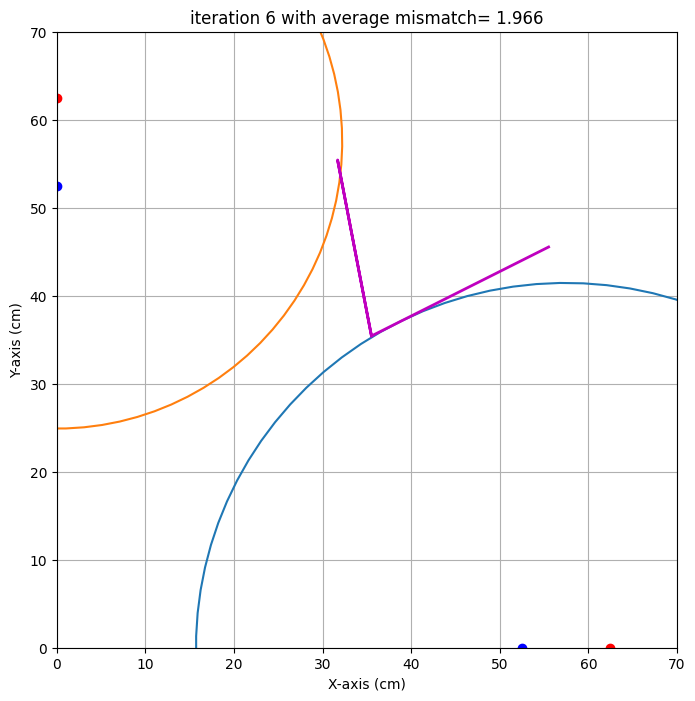

end iteration 6 with average mismatch= 1.966


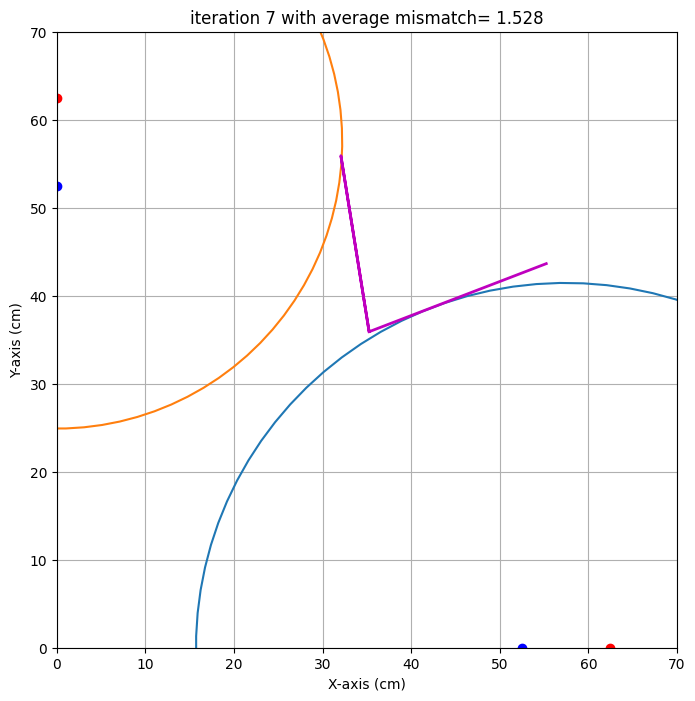

end iteration 7 with average mismatch= 1.528
end iteration 8 with average mismatch= 1.464


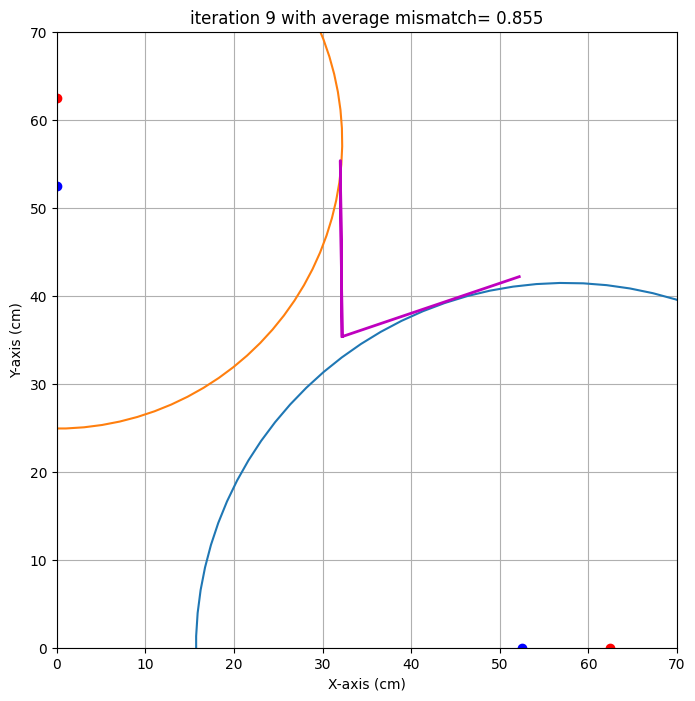

end iteration 9 with average mismatch= 0.855


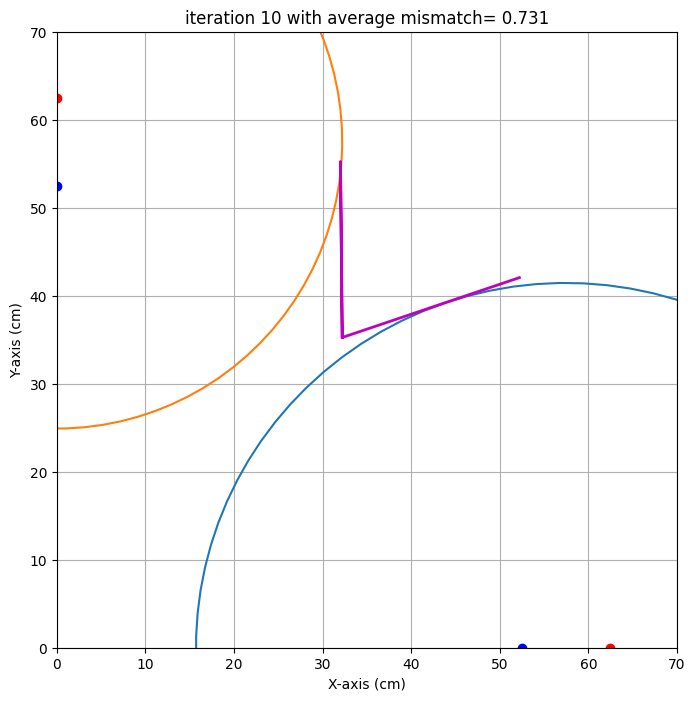

end iteration 10 with average mismatch= 0.731


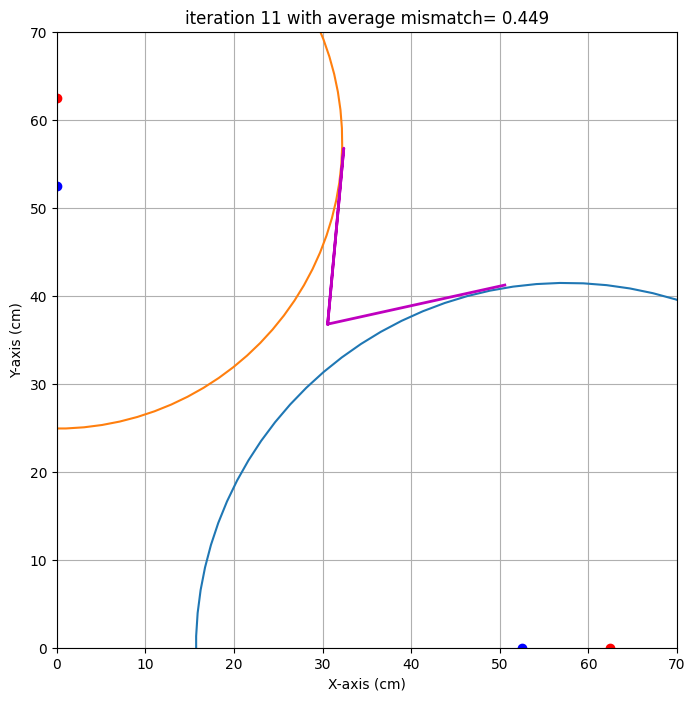

end iteration 11 with average mismatch= 0.449


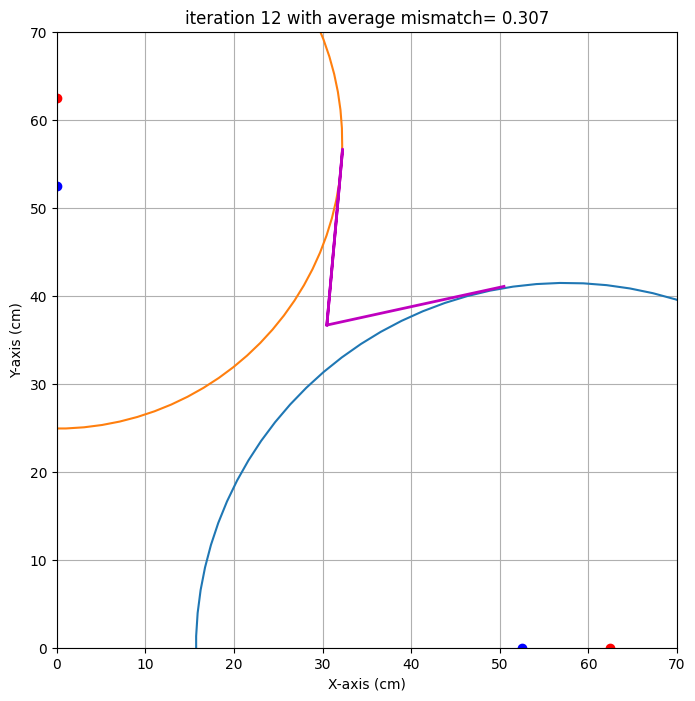

end iteration 12 with average mismatch= 0.307


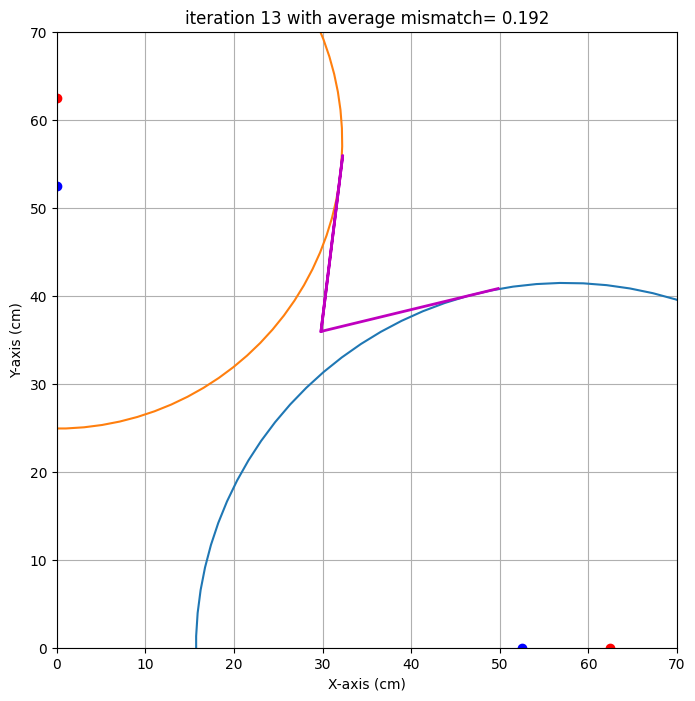

end iteration 13 with average mismatch= 0.192


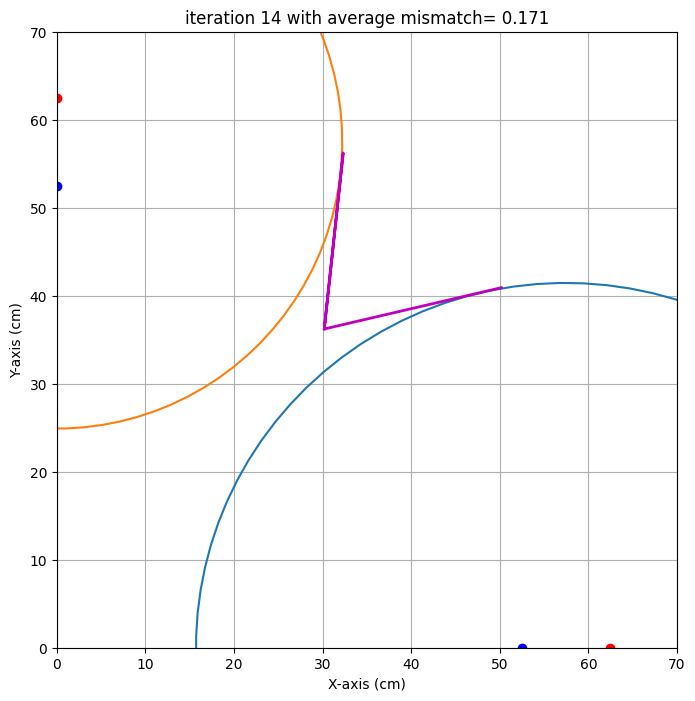

end iteration 14 with average mismatch= 0.171


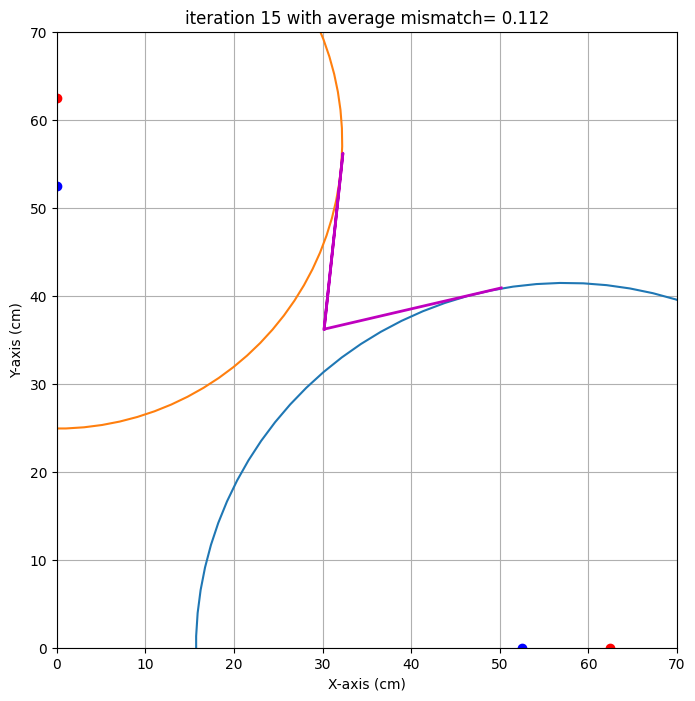

end iteration 15 with average mismatch= 0.112
end iteration 16 with average mismatch= 0.104
end iteration 17 with average mismatch= 0.097


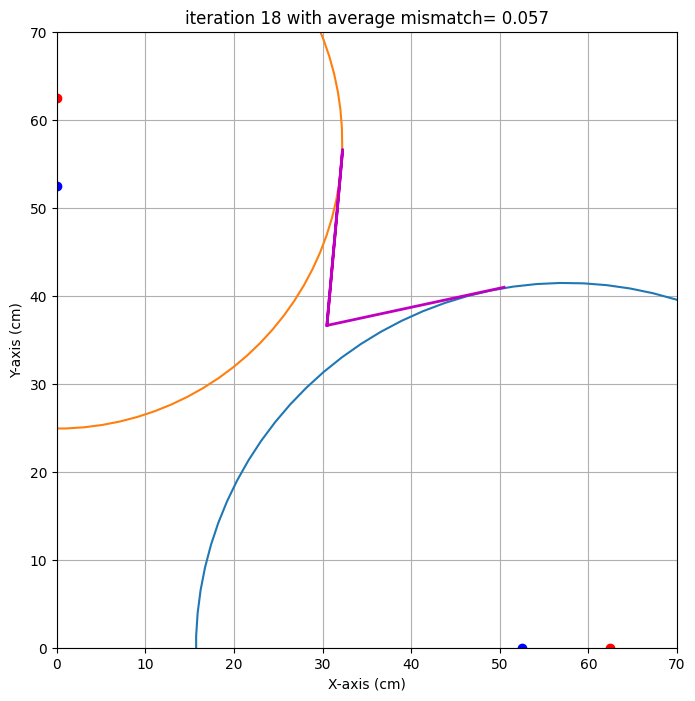

end iteration 18 with average mismatch= 0.057
end iteration 19 with average mismatch= 0.055


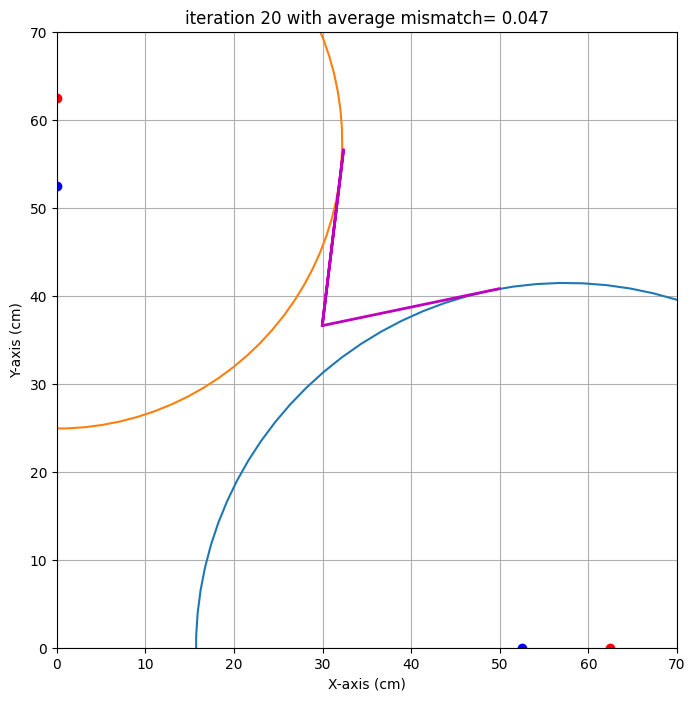

end iteration 20 with average mismatch= 0.047


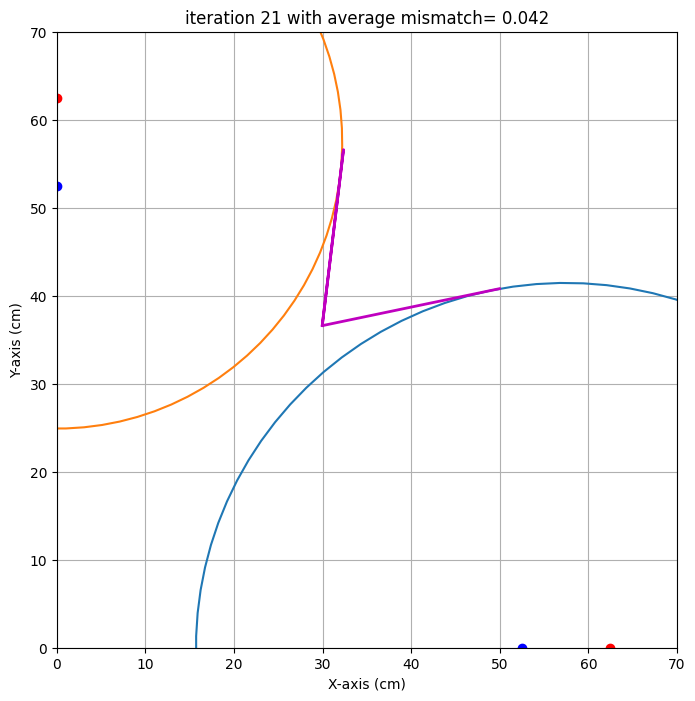

end iteration 21 with average mismatch= 0.042
end iteration 22 with average mismatch= 0.040
end iteration 23 with average mismatch= 0.040
end iteration 24 with average mismatch= 0.040
end iteration 25 with average mismatch= 0.040
end iteration 26 with average mismatch= 0.040
end iteration 27 with average mismatch= 0.040
end iteration 28 with average mismatch= 0.040
end iteration 29 with average mismatch= 0.040
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.040
###############################################################################
end of iteration  30
Best alpha=  11.85 with uncertainty=  12.61
Best beta =   6.85 with uncertainty=  13.03
Best x0   =  29.95 with uncertainty=   4.83
Best y0   =  36.60 with uncertainty=   4.99
###############################################################################


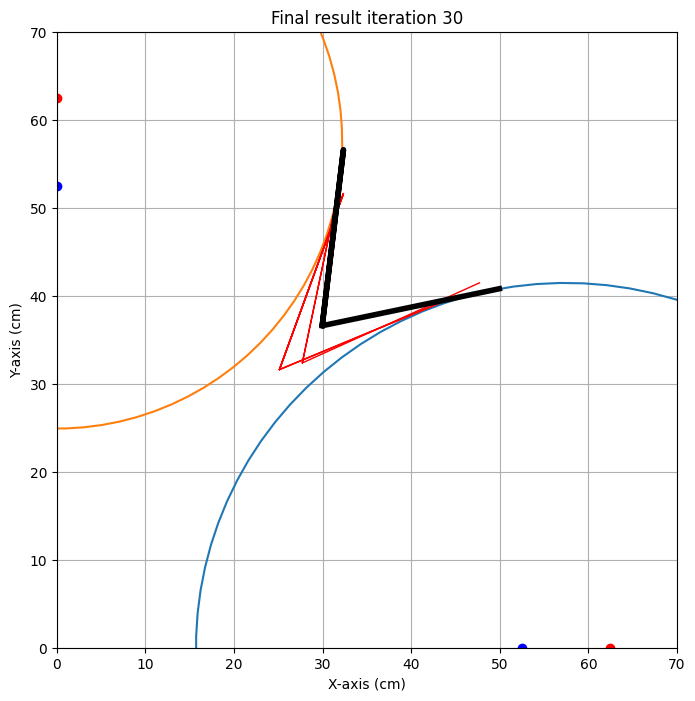

{'alpha': np.float64(11.853043696904857), 'alpha_eps': np.float64(12.610746947177672), 'beta': np.float64(6.845787286393006), 'beta_eps': np.float64(13.030786086228165), 'x0': np.float64(29.95196199011388), 'x0_eps': np.float64(4.828207350362618), 'y0': np.float64(36.59536273185412), 'y0_eps': np.float64(4.988204658335121)}
Matteo Leonardi
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  70   0  50   0  87.8
1  60   0  40   0  79.6
2  60   0  50   0  81.5
3   0  70   0  50  67.9
4   0  60   0  40  63.6
5   0  60   0  50  63.2


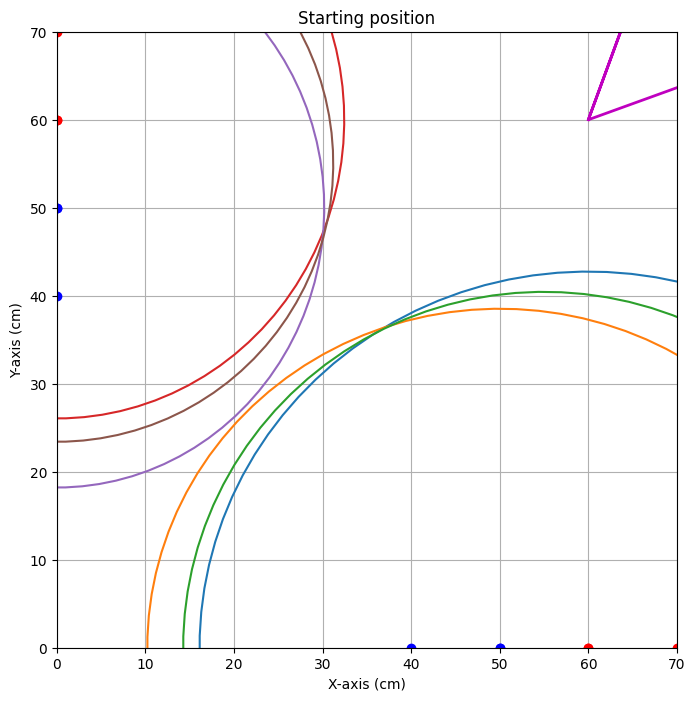


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=53.671


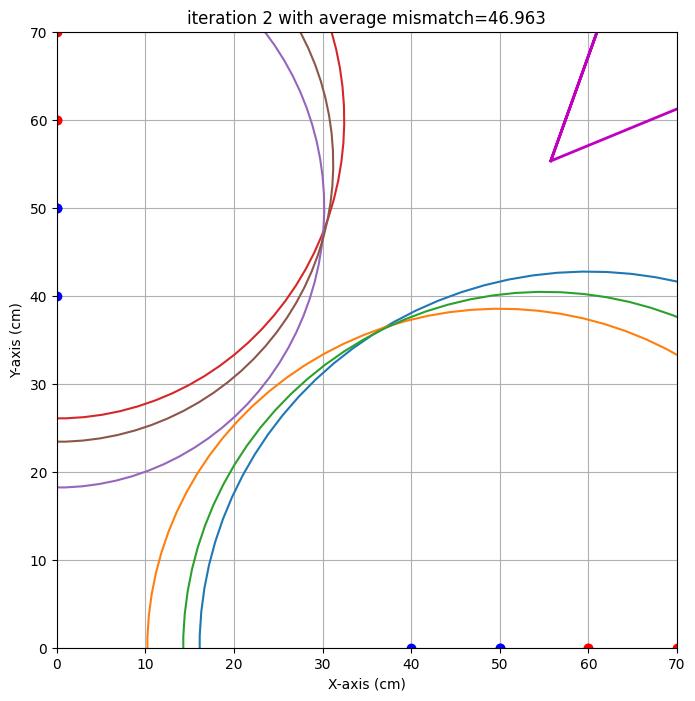

end iteration 2 with average mismatch=46.963


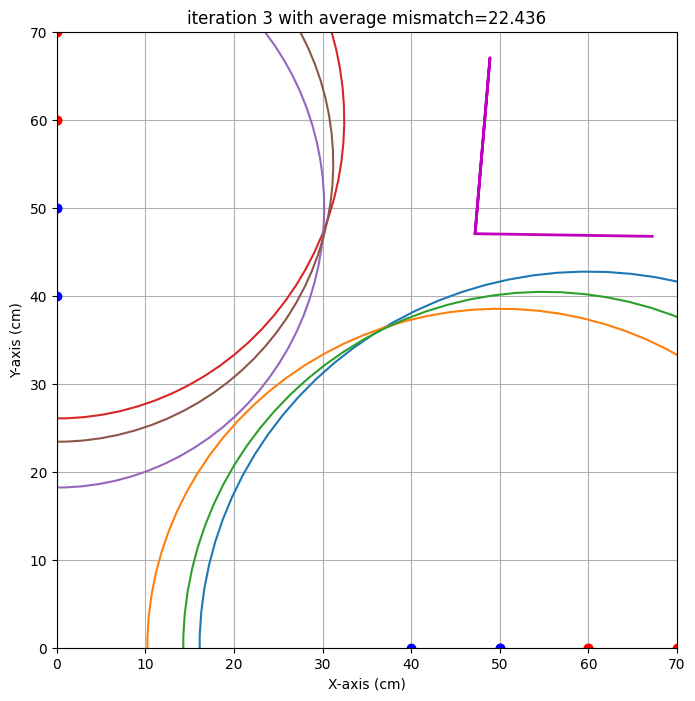

end iteration 3 with average mismatch=22.436


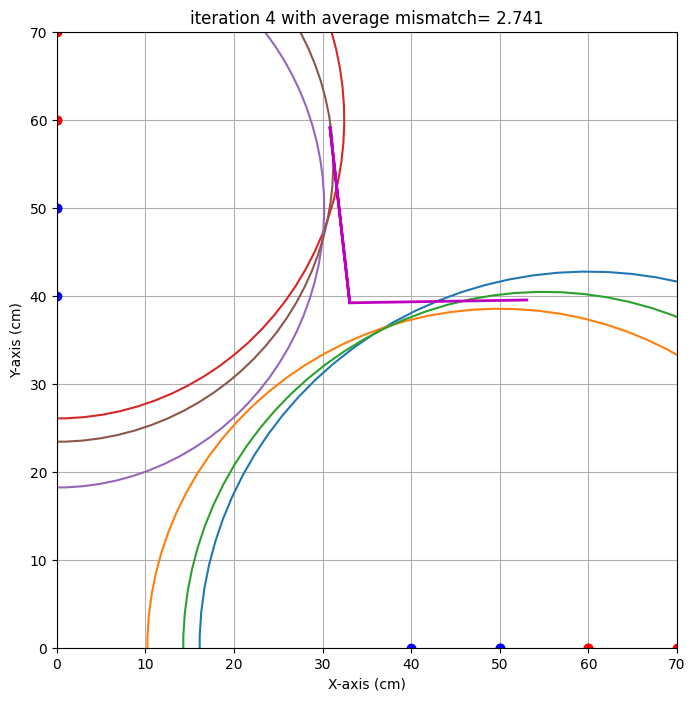

end iteration 4 with average mismatch= 2.741


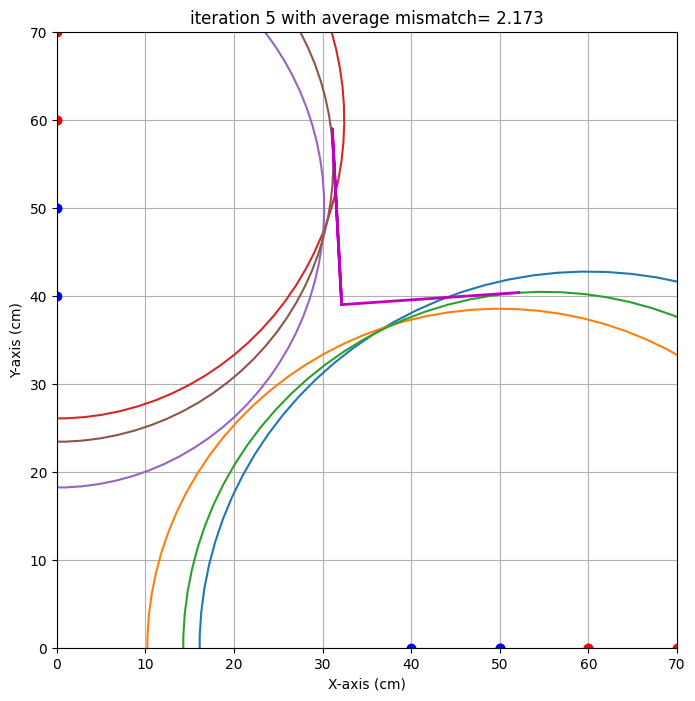

end iteration 5 with average mismatch= 2.173


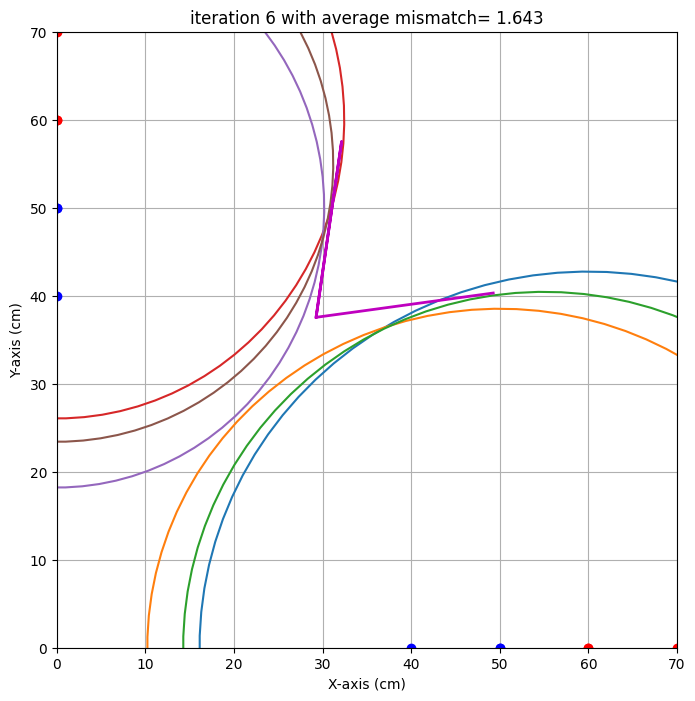

end iteration 6 with average mismatch= 1.643


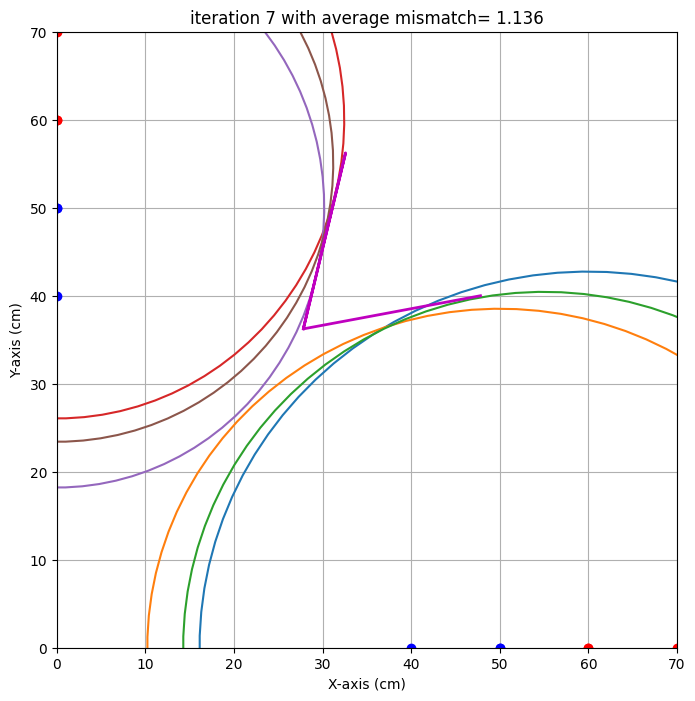

end iteration 7 with average mismatch= 1.136
end iteration 8 with average mismatch= 1.043


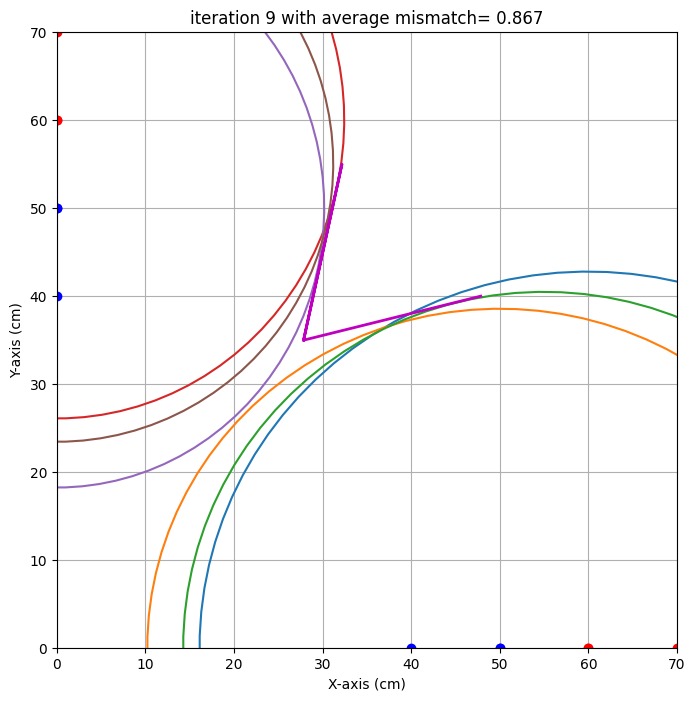

end iteration 9 with average mismatch= 0.867
end iteration 10 with average mismatch= 0.858
end iteration 11 with average mismatch= 0.856
end iteration 12 with average mismatch= 0.855
end iteration 13 with average mismatch= 0.855
end iteration 14 with average mismatch= 0.852


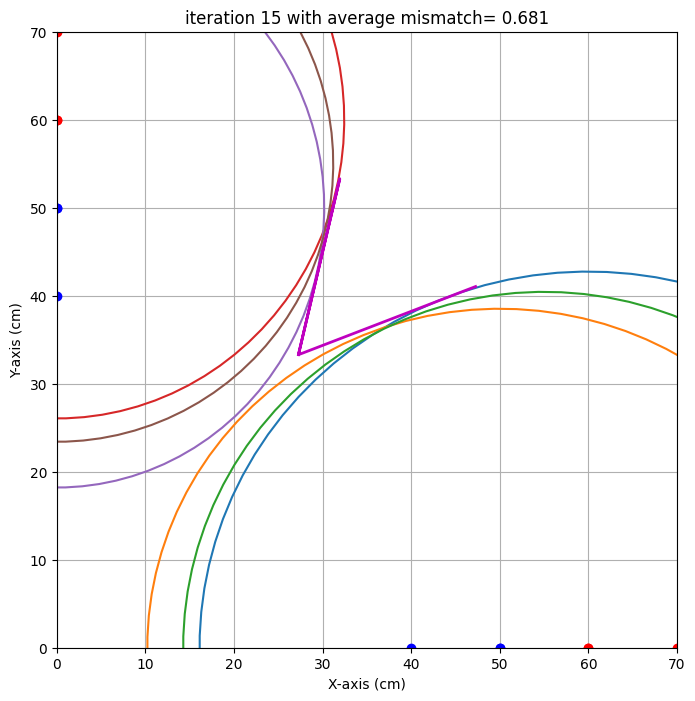

end iteration 15 with average mismatch= 0.681


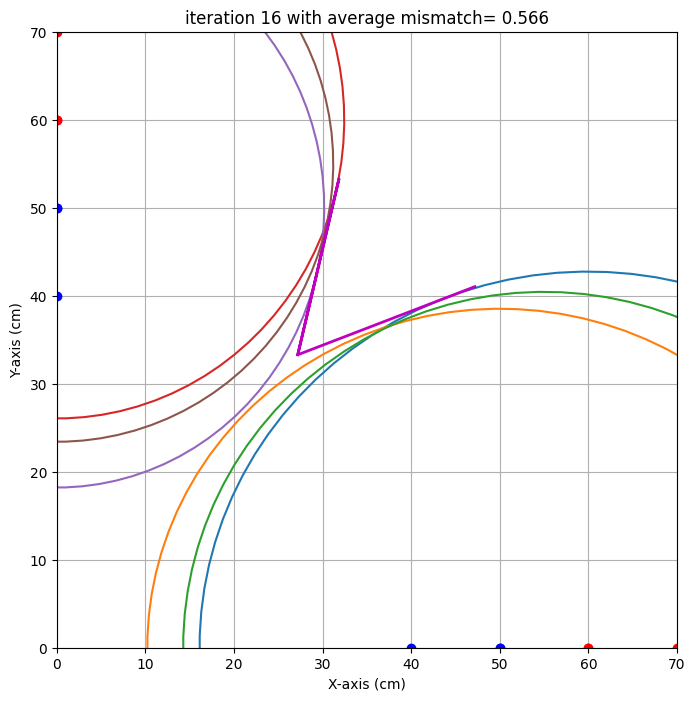

end iteration 16 with average mismatch= 0.566
end iteration 17 with average mismatch= 0.514
end iteration 18 with average mismatch= 0.485
end iteration 19 with average mismatch= 0.450
end iteration 20 with average mismatch= 0.447
end iteration 21 with average mismatch= 0.446
end iteration 22 with average mismatch= 0.445
end iteration 23 with average mismatch= 0.445
end iteration 24 with average mismatch= 0.445
end iteration 25 with average mismatch= 0.445
end iteration 26 with average mismatch= 0.445
end iteration 27 with average mismatch= 0.445
end iteration 28 with average mismatch= 0.406
end iteration 29 with average mismatch= 0.397
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.394
###############################################################################
end of iteration  30
Best alpha=  23.66 with uncertainty=   3.37
Best beta =  13.21 with uncertainty=   3.61
Best x0   = 

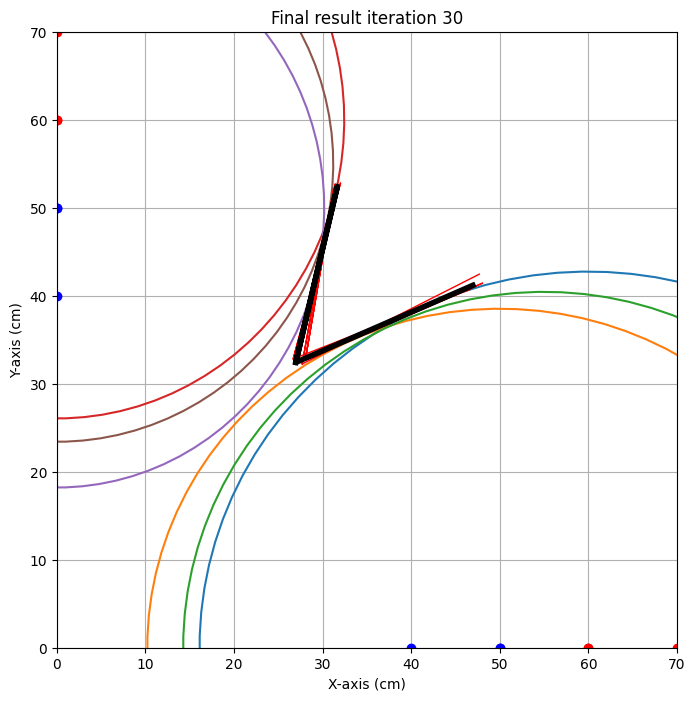

{'alpha': np.float64(23.662155264345568), 'alpha_eps': np.float64(3.3738310401063885), 'beta': np.float64(13.207085315689273), 'beta_eps': np.float64(3.6142009868699887), 'x0': np.float64(26.96429403939321), 'x0_eps': np.float64(1.0760248026164199), 'y0': np.float64(32.41852285117179), 'y0_eps': np.float64(0.4040003435422932)}


In [9]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [10]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Yael Jawahierkhan 
x0 target is : 24.0. Gevonden waarde: 30.0 cm met een standaardafwijking van 4.8 cm 
y0 target is : 31.0. Gevonden waarde: 36.6 cm met een standaardafwijking van 5.0 cm 
alpha target is : 25.0. Gevonden waarde: 11.9 graden met een standaardafwijking van 12.6 graad 
beta target is : 10.0. Gevonden waarde: 6.8 graden met een standaardafwijking van 13.0 graad 

Matteo Leonardi 
x0 target is : 24.0. Gevonden waarde: 27.0 cm met een standaardafwijking van 1.1 cm 
y0 target is : 31.0. Gevonden waarde: 32.4 cm met een standaardafwijking van 0.4 cm 
alpha target is : 25.0. Gevonden waarde: 23.7 graden met een standaardafwijking van 3.4 graad 
beta target is : 10.0. Gevonden waarde: 13.2 graden met een standaardafwijking van 3.6 graad 



## Opdracht 8: Iteratie1+. 14:49.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: 

![Alt](tudelftLogo.png)


In [11]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  70   0  50   0  87.8
1  60   0  40   0  79.6
2  60   0  50   0  81.5
3   0  70   0  50  67.9
4   0  60   0  40  63.6
5   0  60   0  50  63.2
6  70   0  40   0  84.4
7   0  70   0  40  68.7


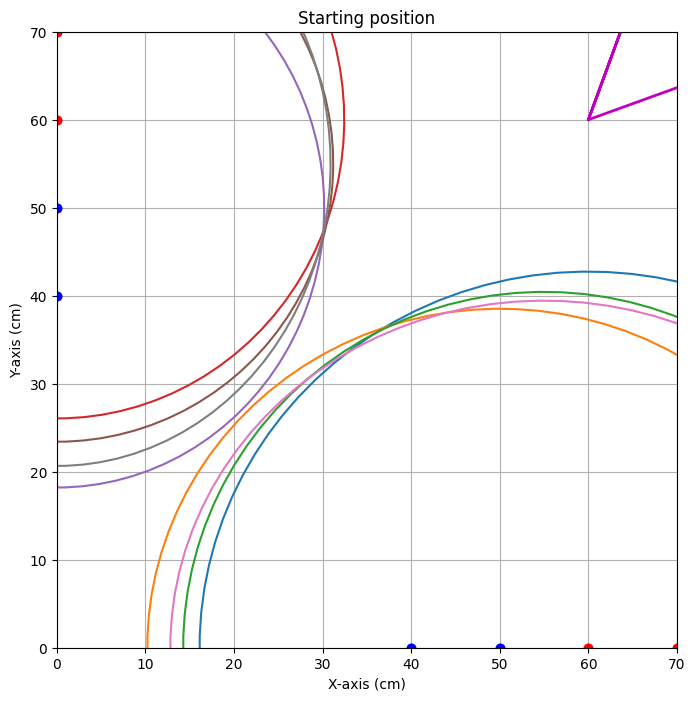


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=53.529


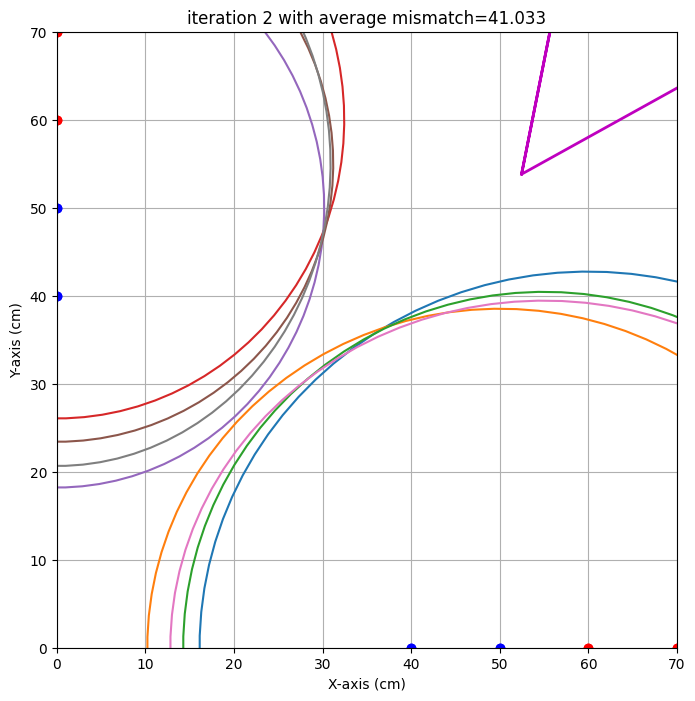

end iteration 2 with average mismatch=41.033


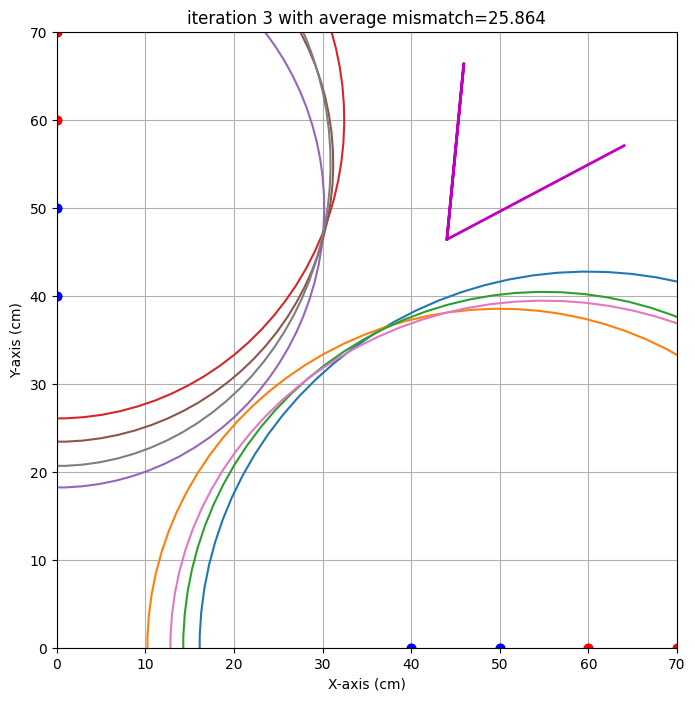

end iteration 3 with average mismatch=25.864


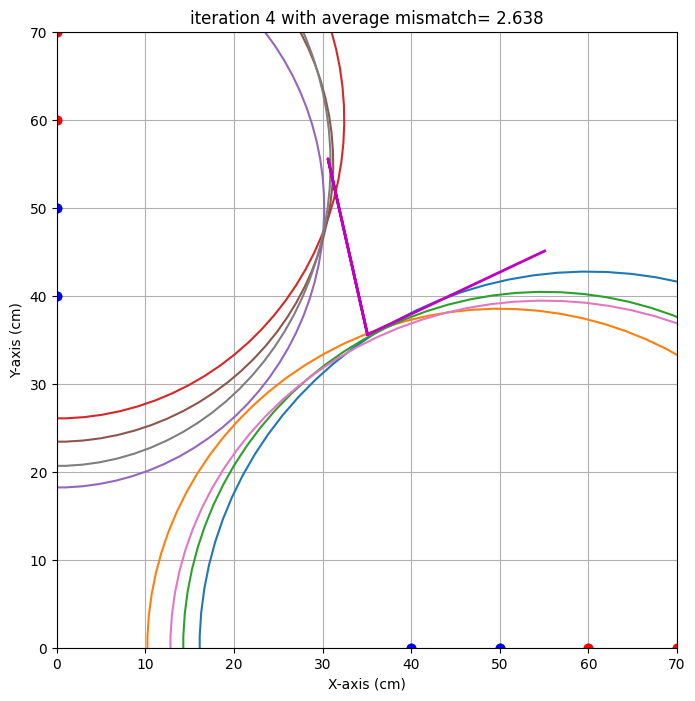

end iteration 4 with average mismatch= 2.638
end iteration 5 with average mismatch= 2.596
end iteration 6 with average mismatch= 2.507
end iteration 7 with average mismatch= 2.277


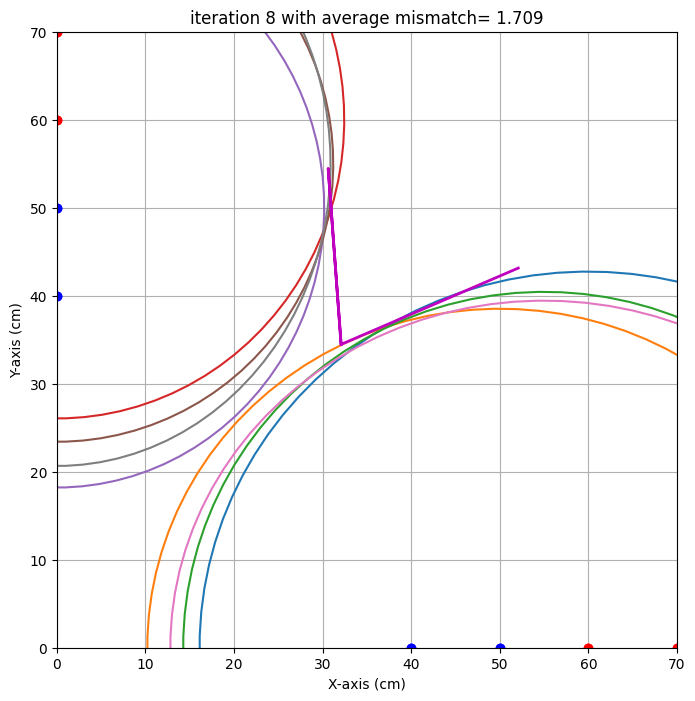

end iteration 8 with average mismatch= 1.709


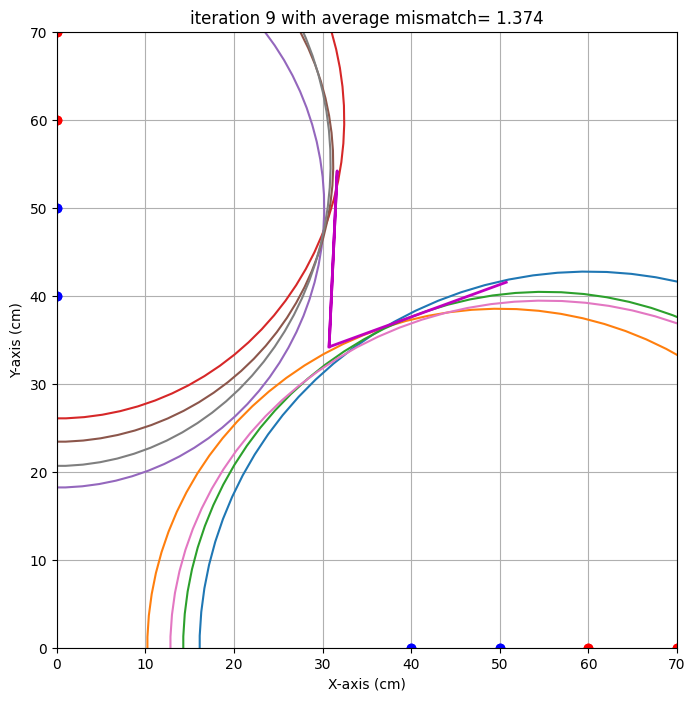

end iteration 9 with average mismatch= 1.374


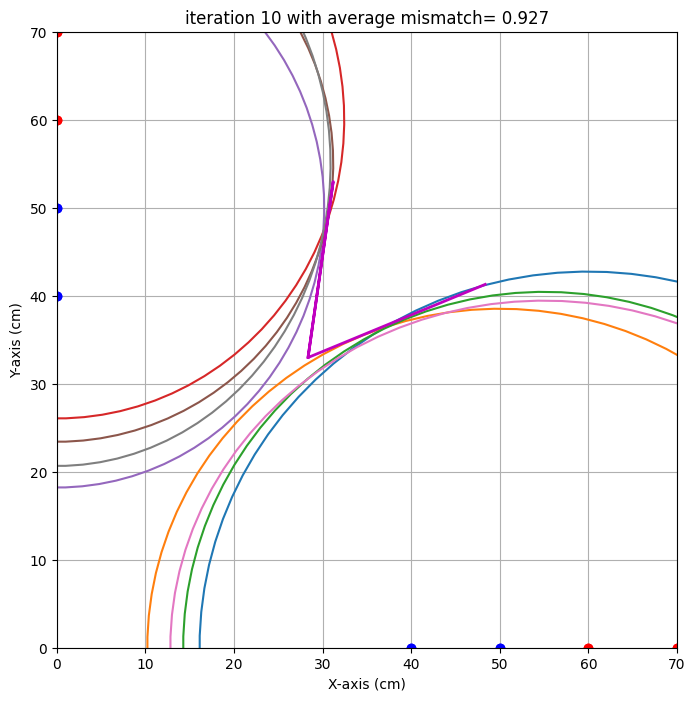

end iteration 10 with average mismatch= 0.927
end iteration 11 with average mismatch= 0.880
end iteration 12 with average mismatch= 0.873


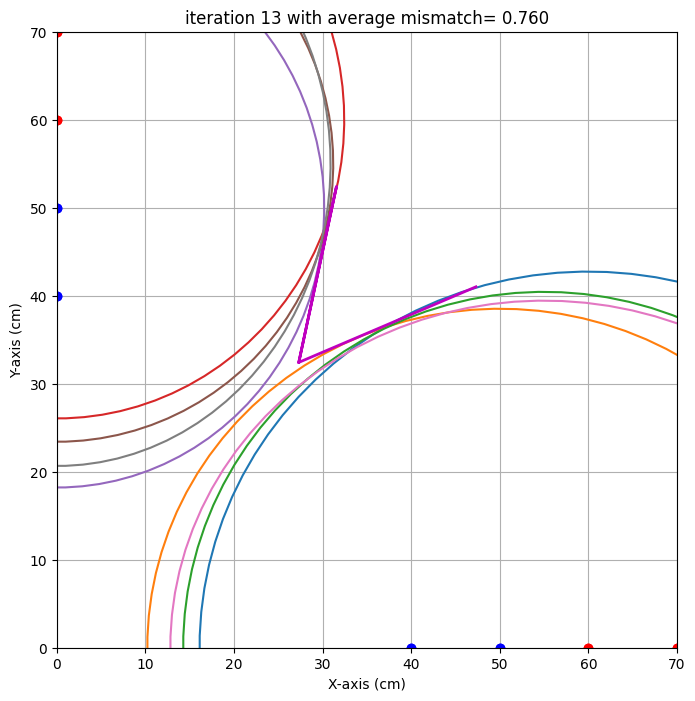

end iteration 13 with average mismatch= 0.760
end iteration 14 with average mismatch= 0.725
end iteration 15 with average mismatch= 0.717
end iteration 16 with average mismatch= 0.713
end iteration 17 with average mismatch= 0.701
end iteration 18 with average mismatch= 0.698
end iteration 19 with average mismatch= 0.689
end iteration 20 with average mismatch= 0.687
end iteration 21 with average mismatch= 0.687
end iteration 22 with average mismatch= 0.687
end iteration 23 with average mismatch= 0.687
end iteration 24 with average mismatch= 0.687


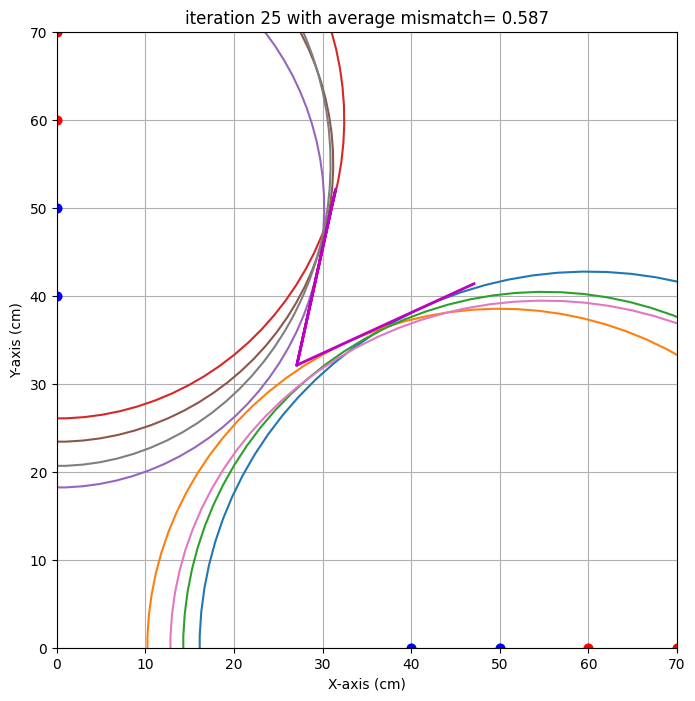

end iteration 25 with average mismatch= 0.587
end iteration 26 with average mismatch= 0.577
end iteration 27 with average mismatch= 0.570
end iteration 28 with average mismatch= 0.570
end iteration 29 with average mismatch= 0.569
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.569
###############################################################################
end of iteration  30
Best alpha=  24.80 with uncertainty=   6.22
Best beta =  12.32 with uncertainty=   5.84
Best x0   =  27.06 with uncertainty=   2.14
Best y0   =  32.10 with uncertainty=   1.68
###############################################################################


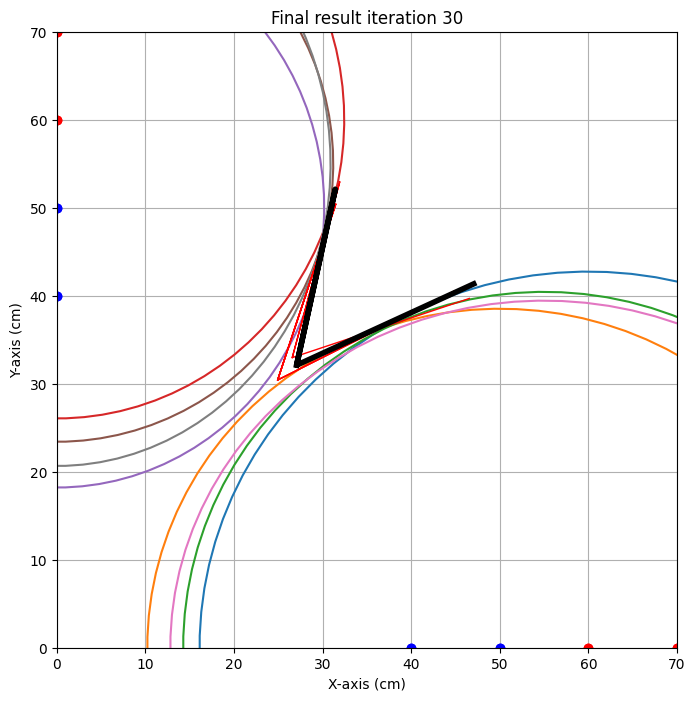

{'alpha': np.float64(24.802487931647747), 'alpha_eps': np.float64(6.220795389463788), 'beta': np.float64(12.320850048006564), 'beta_eps': np.float64(5.837584733585585), 'x0': np.float64(27.06155787556559), 'x0_eps': np.float64(2.1387088776394236), 'y0': np.float64(32.10403569086665), 'y0_eps': np.float64(1.6824763233518958)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  70   0  50   0  72.2
1  60   0  40   0  70.6
2  60   0  50   0  69.0
3   0  70   0  50  94.5
4   0  60   0  40  93.5
5   0  60   0  50  90.4
6  70   0  40   0  75.4
7   0  70   0  40  93.4


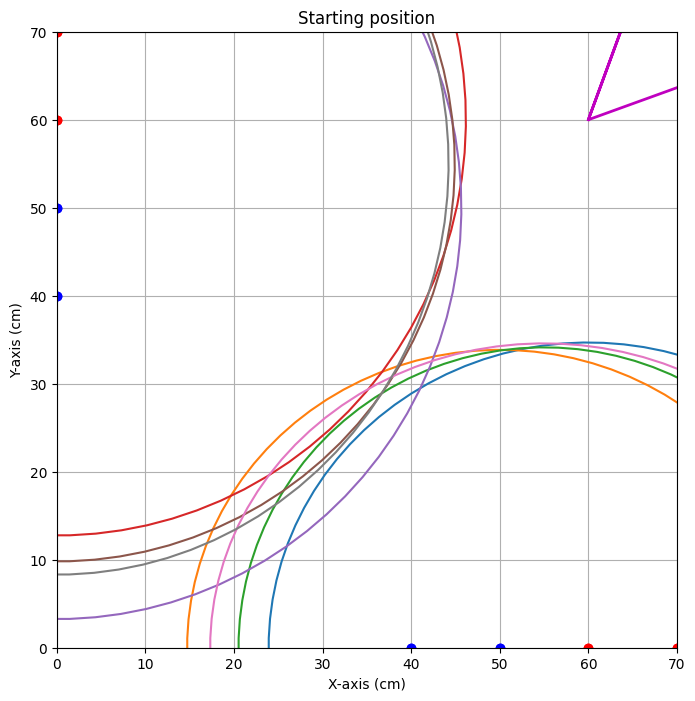


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=45.741


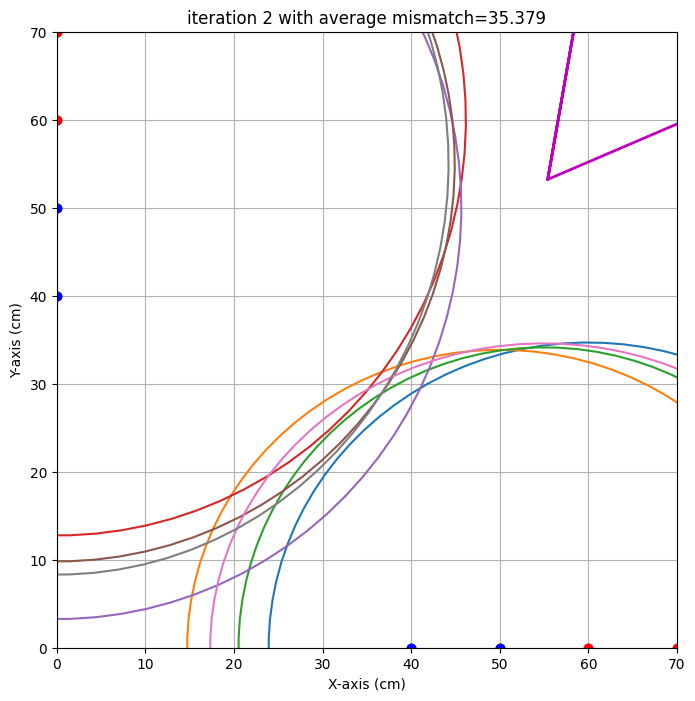

end iteration 2 with average mismatch=35.379


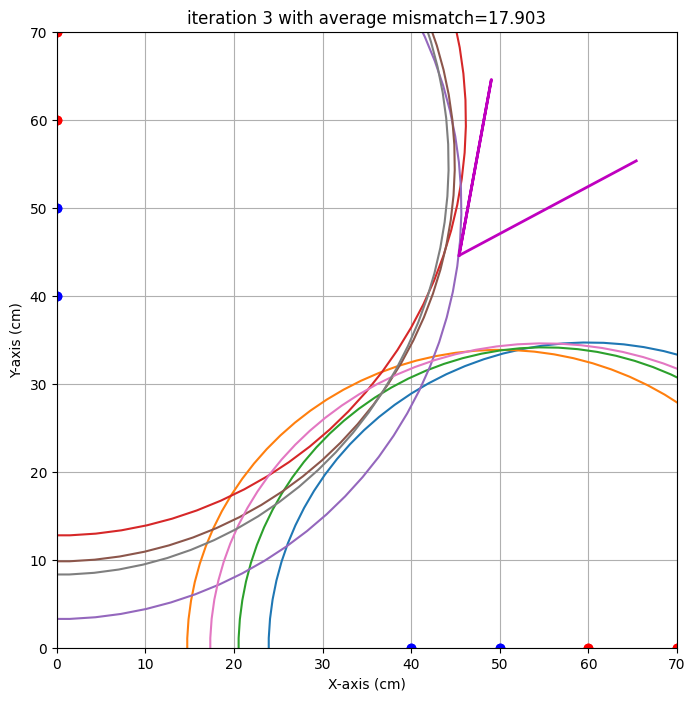

end iteration 3 with average mismatch=17.903


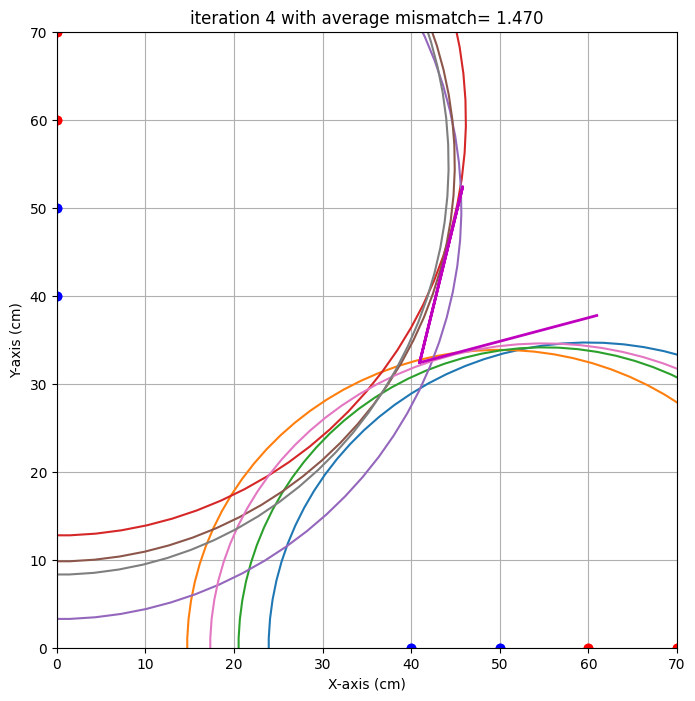

end iteration 4 with average mismatch= 1.470


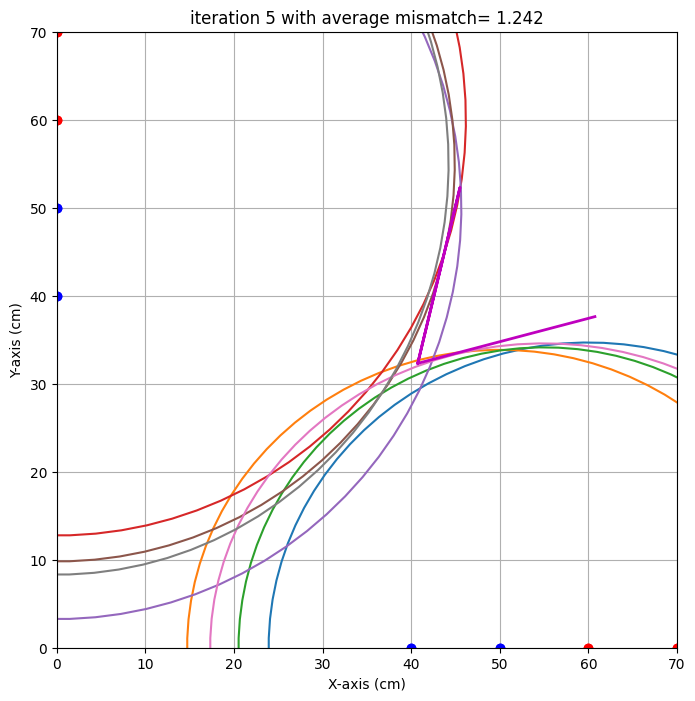

end iteration 5 with average mismatch= 1.242


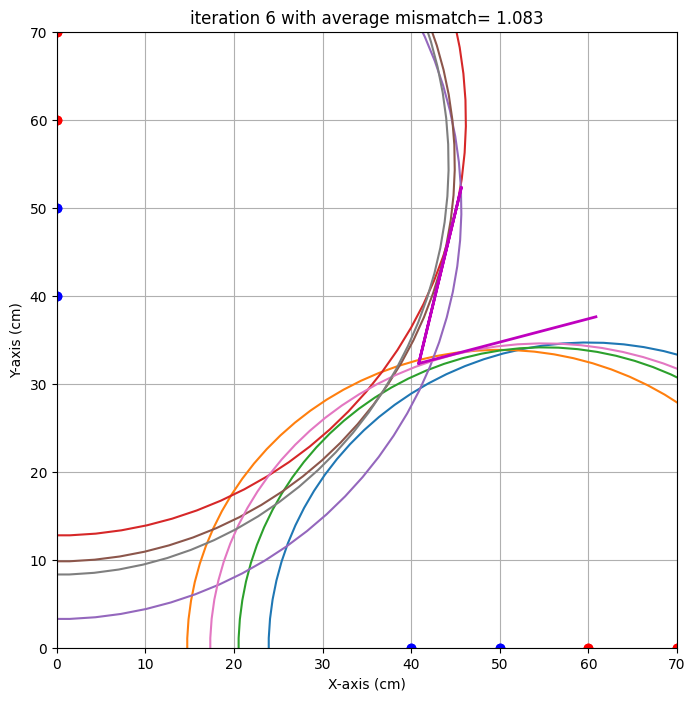

end iteration 6 with average mismatch= 1.083
end iteration 7 with average mismatch= 1.082


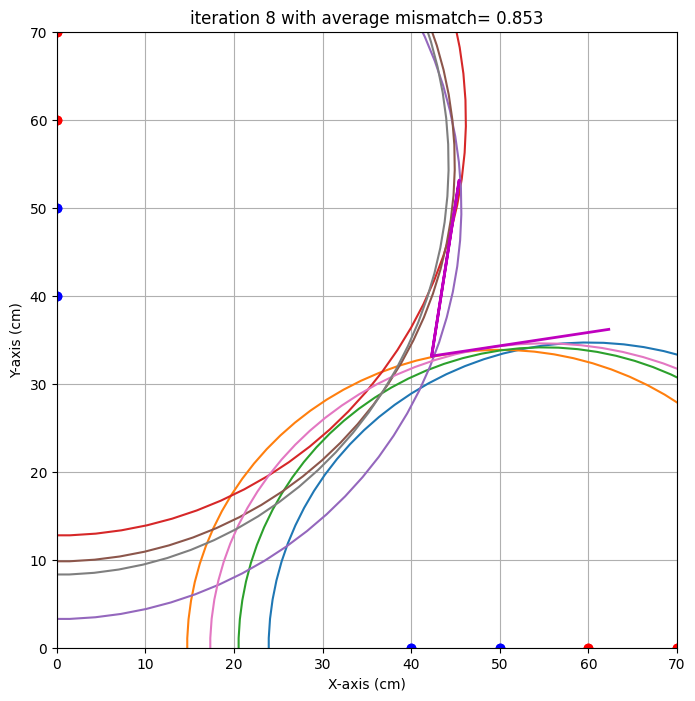

end iteration 8 with average mismatch= 0.853
end iteration 9 with average mismatch= 0.810
end iteration 10 with average mismatch= 0.810
end iteration 11 with average mismatch= 0.810


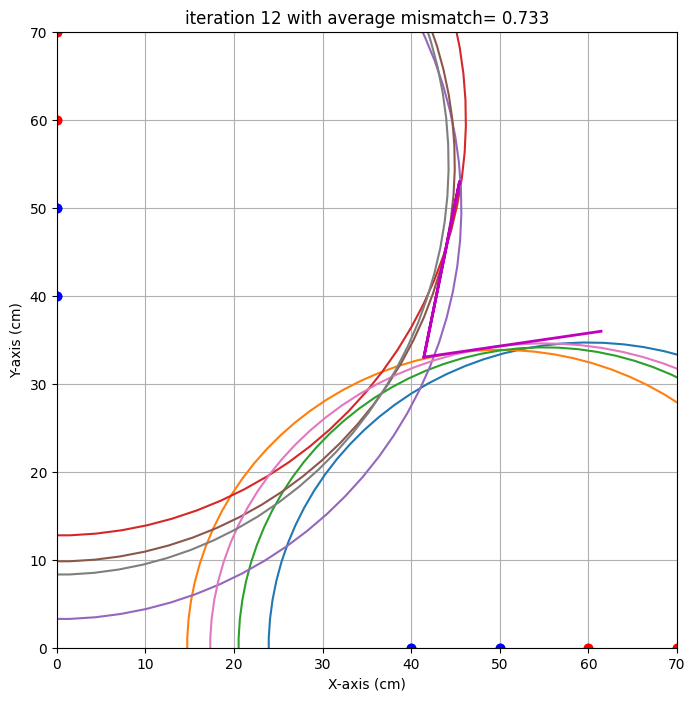

end iteration 12 with average mismatch= 0.733
end iteration 13 with average mismatch= 0.733
end iteration 14 with average mismatch= 0.733
end iteration 15 with average mismatch= 0.733
end iteration 16 with average mismatch= 0.733
end iteration 17 with average mismatch= 0.733
end iteration 18 with average mismatch= 0.733
end iteration 19 with average mismatch= 0.733
end iteration 20 with average mismatch= 0.733
end iteration 21 with average mismatch= 0.733
end iteration 22 with average mismatch= 0.733
end iteration 23 with average mismatch= 0.733
end iteration 24 with average mismatch= 0.733
end iteration 25 with average mismatch= 0.733
end iteration 26 with average mismatch= 0.733
end iteration 27 with average mismatch= 0.733
end iteration 28 with average mismatch= 0.733
end iteration 29 with average mismatch= 0.733
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.733
#################

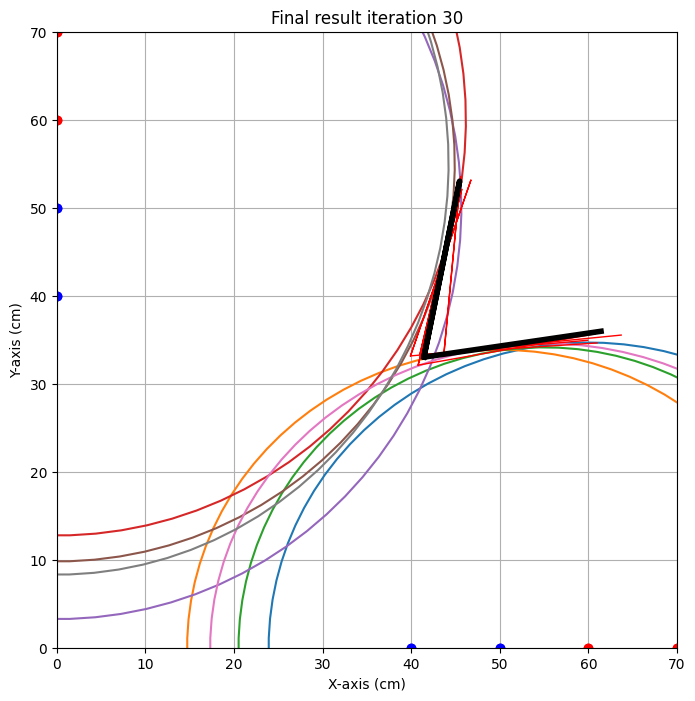

{'alpha': np.float64(8.365551663456566), 'alpha_eps': np.float64(4.597028072110647), 'beta': np.float64(11.405544547344967), 'beta_eps': np.float64(7.450422012728332), 'x0': np.float64(41.4339552877926), 'x0_eps': np.float64(2.2728372014078957), 'y0': np.float64(33.01935538645165), 'y0_eps': np.float64(0.910461255763316)}
locatie 1 
x0 target is : 24.0. Gevonden waarde: 27.1 cm met een standaardafwijking van 2.1 cm 
y0 target is : 31.0. Gevonden waarde: 32.1 cm met een standaardafwijking van 1.7 cm 
alpha target is : 25.0. Gevonden waarde: 24.8 graden met een standaardafwijking van 6.2 graad 
beta target is : 10.0. Gevonden waarde: 12.3 graden met een standaardafwijking van 5.8 graad 

locatie 2 
x0 target is : 37.0. Gevonden waarde: 41.4 cm met een standaardafwijking van 2.3 cm 
y0 target is : 32.9. Gevonden waarde: 33.0 cm met een standaardafwijking van 0.9 cm 
alpha target is : 4.0. Gevonden waarde: 8.4 graden met een standaardafwijking van 4.6 graad 
beta target is : 23.0. Gevonden

In [12]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 24,
                    'y0': 31,
                    'alpha' : 25,
                    'beta' : 10},
           'locatie 2':{'x0': 37 ,
                    'y0': 32.9,
                    'alpha' : 4 ,
                    'beta' : 23 }
            }
           
# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
      [70,0,50,0,87.8],
    [60,0,40,0,79.6],
    [60,0,50,0,81.5],
    [0,70,0,50,67.9],  
    [0,60,0,40,63.6],
    [0,60,0,50,63.2],
    [70,0,40,0,84.4],
    [0,70,0,40,68.7],
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
      [70,0,50,0,72.2],
    [60,0,40,0,70.6],
    [60,0,50,0,69.0],
    [0,70,0,50,94.5],  
    [0,60,0,40,93.5],
    [0,60,0,50,90.4],
    [70,0,40,0,75.4],
    [0,70,0,40,93.4],
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

Iteratie 2:

locatie 1
Running the imaging algorithm with the following data:
    xs  ys  xr  yr     R
0   70   0  50   0  88.6
1   70   0  70   0  93.6
2   60   0  50   0  86.5
3   65   0  55   0  88.6
4   70   0  55   0  93.3
5   65   0  50   0  88.3
6    0  70   0  50  75.5
7    0  60   0  40  69.5
8    0  60   0  50  66.8
9    0  70   0  40  74.0
10   0  65   0  45  66.1
11   0  70   0  45  69.8


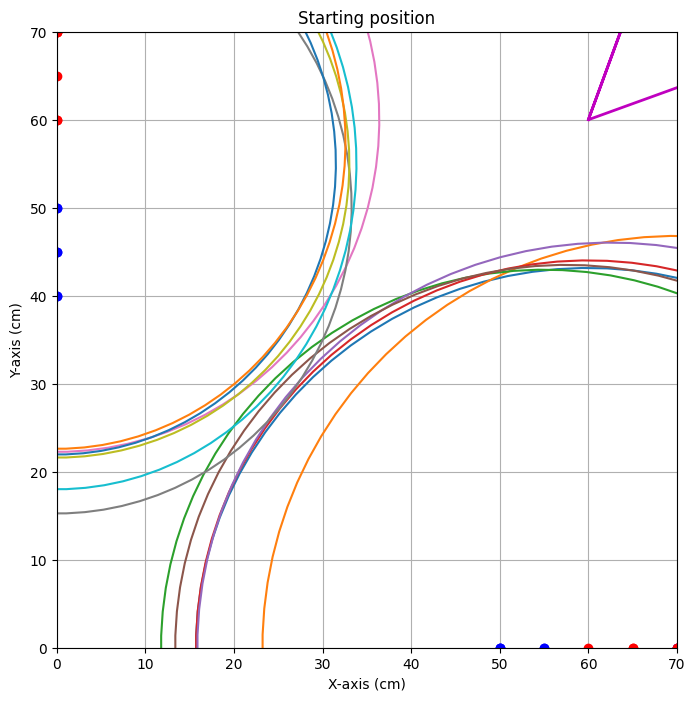


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=47.308


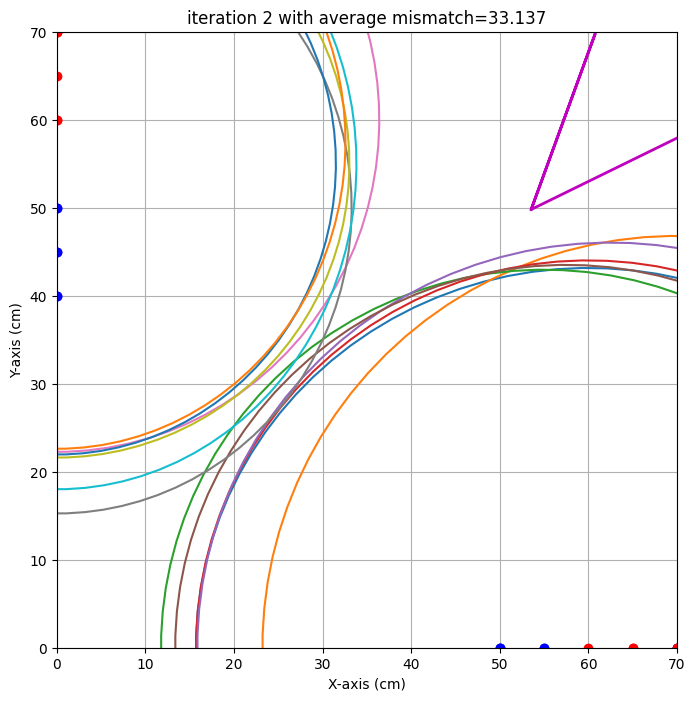

end iteration 2 with average mismatch=33.137


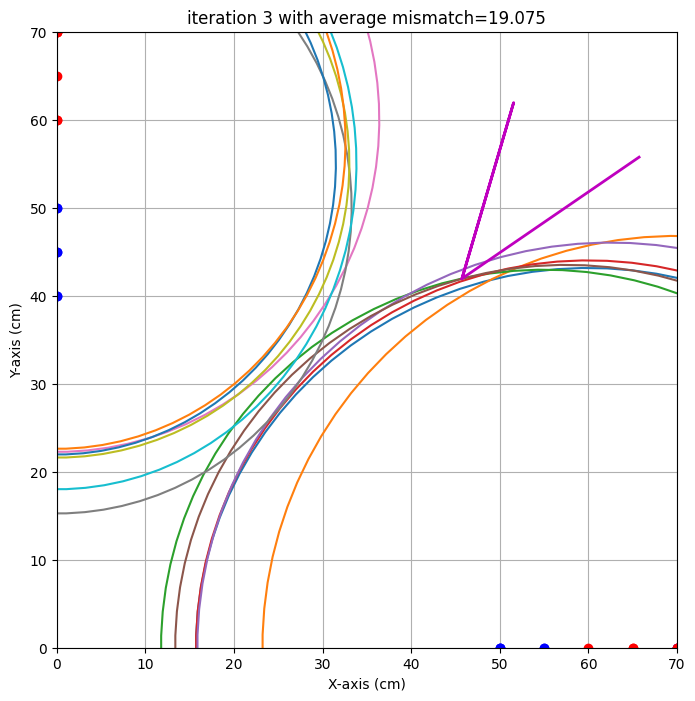

end iteration 3 with average mismatch=19.075


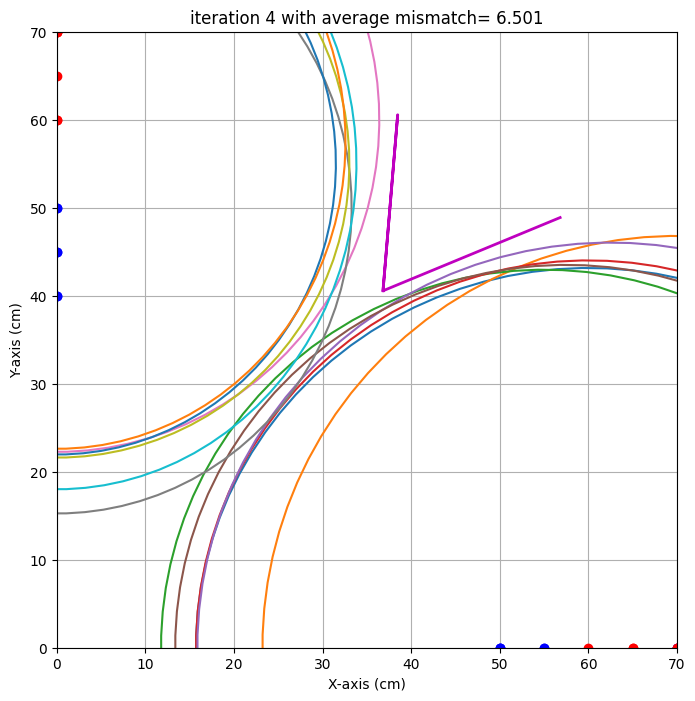

end iteration 4 with average mismatch= 6.501


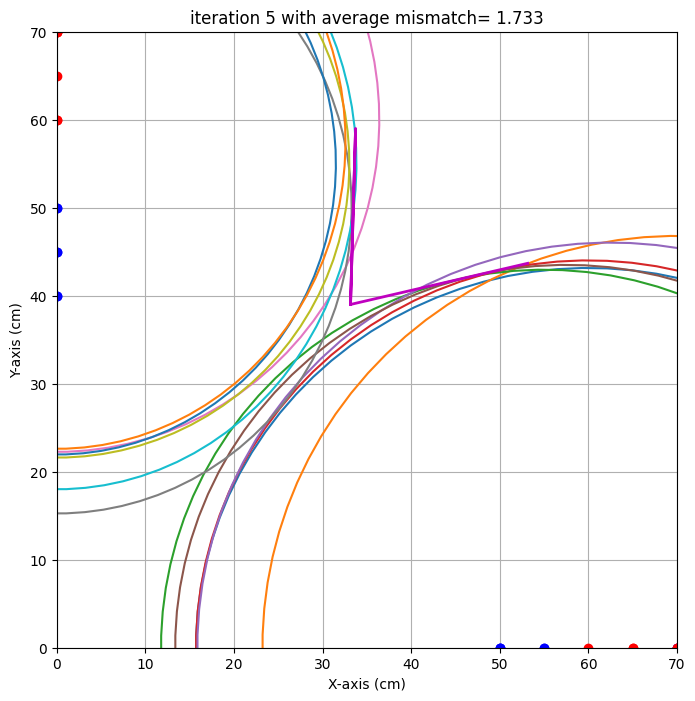

end iteration 5 with average mismatch= 1.733
end iteration 6 with average mismatch= 1.726
end iteration 7 with average mismatch= 1.702
end iteration 8 with average mismatch= 1.677
end iteration 9 with average mismatch= 1.672
end iteration 10 with average mismatch= 1.670
end iteration 11 with average mismatch= 1.670
end iteration 12 with average mismatch= 1.670
end iteration 13 with average mismatch= 1.665
end iteration 14 with average mismatch= 1.660
end iteration 15 with average mismatch= 1.643
end iteration 16 with average mismatch= 1.627
end iteration 17 with average mismatch= 1.593
end iteration 18 with average mismatch= 1.577
end iteration 19 with average mismatch= 1.562
end iteration 20 with average mismatch= 1.560
end iteration 21 with average mismatch= 1.560
end iteration 22 with average mismatch= 1.560
end iteration 23 with average mismatch= 1.560
end iteration 24 with average mismatch= 1.560
end iteration 25 with average mismatch= 1.560
end iteration 26 with average mismatch=

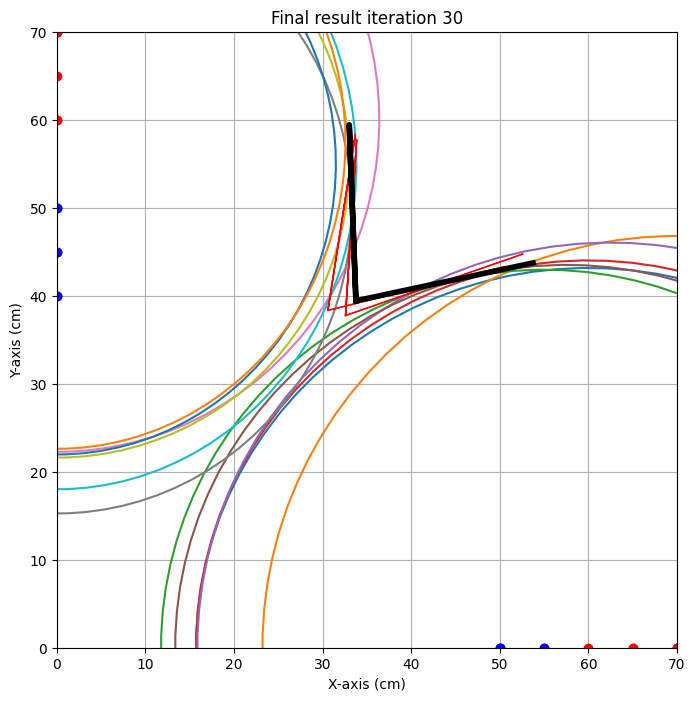

{'alpha': np.float64(12.151529412775211), 'alpha_eps': np.float64(7.096424985265347), 'beta': np.float64(-2.1585171670946033), 'beta_eps': np.float64(10.966951686849422), 'x0': np.float64(33.76062997716911), 'x0_eps': np.float64(3.163833271335392), 'y0': np.float64(39.422770139086985), 'y0_eps': np.float64(1.677116392246269)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  70   0  50   0  72.2
1  60   0  40   0  70.6
2  60   0  50   0  69.0
3   0  70   0  50  94.5
4   0  60   0  40  93.5
5   0  60   0  50  90.4
6  70   0  40   0  75.4
7   0  70   0  40  93.4


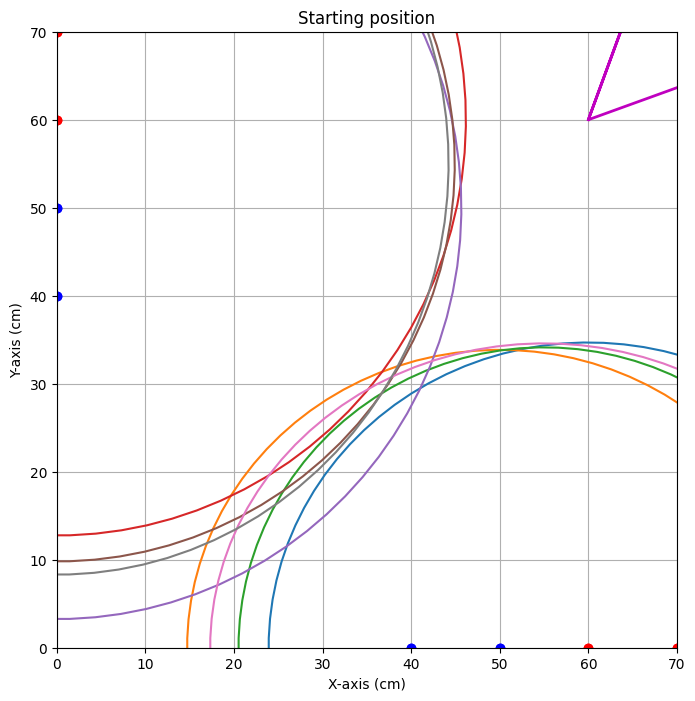


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=45.741


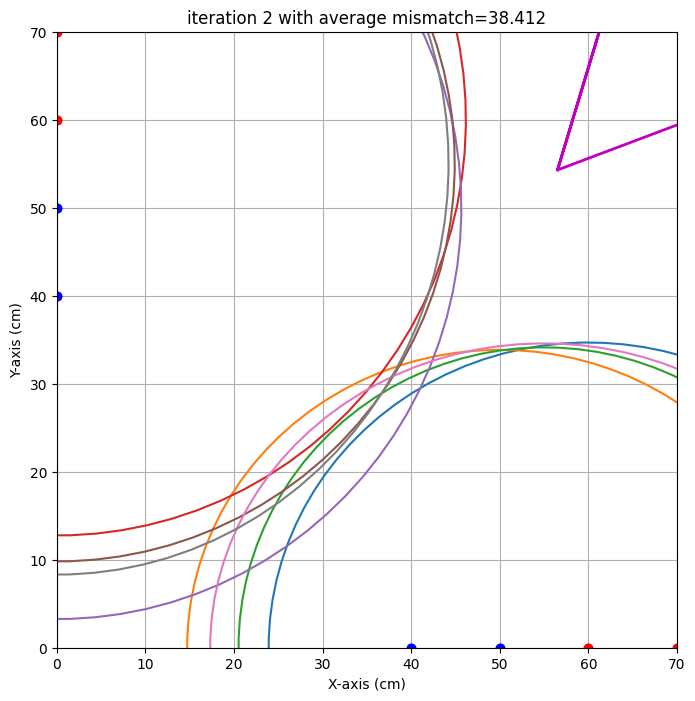

end iteration 2 with average mismatch=38.412


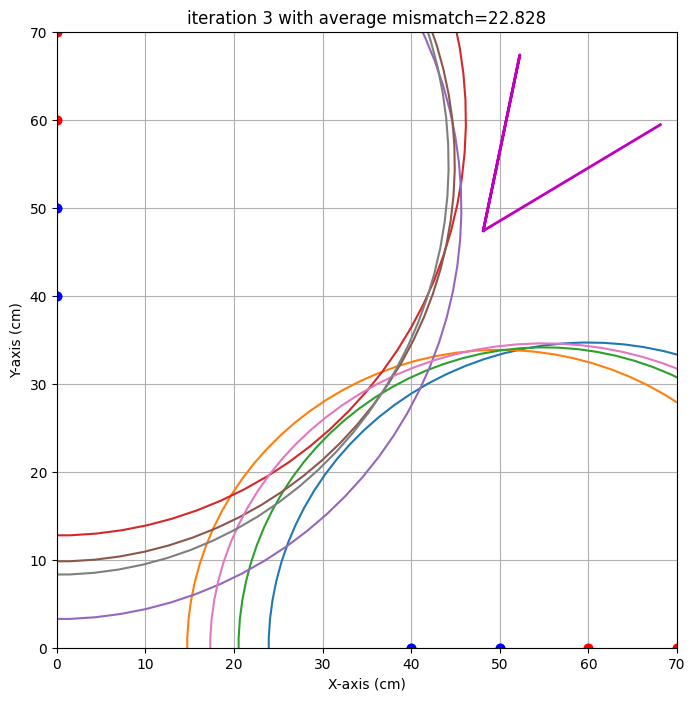

end iteration 3 with average mismatch=22.828


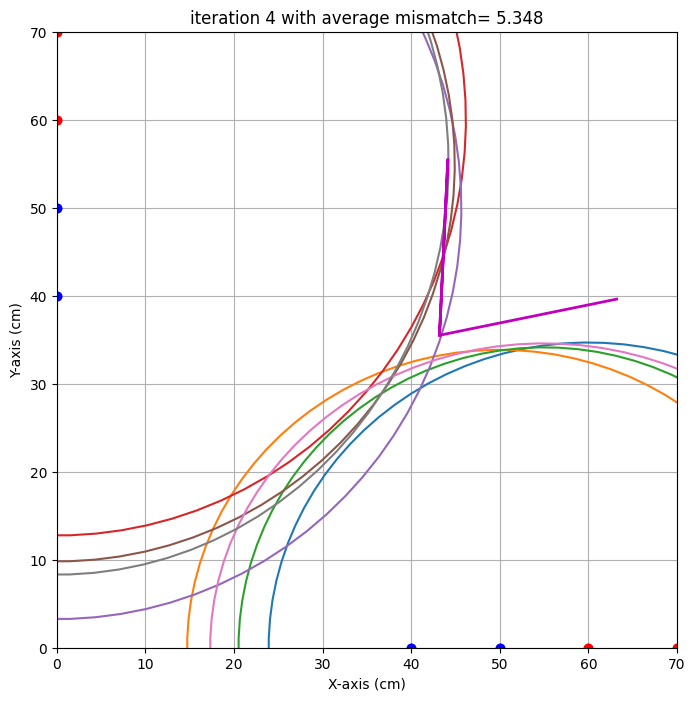

end iteration 4 with average mismatch= 5.348


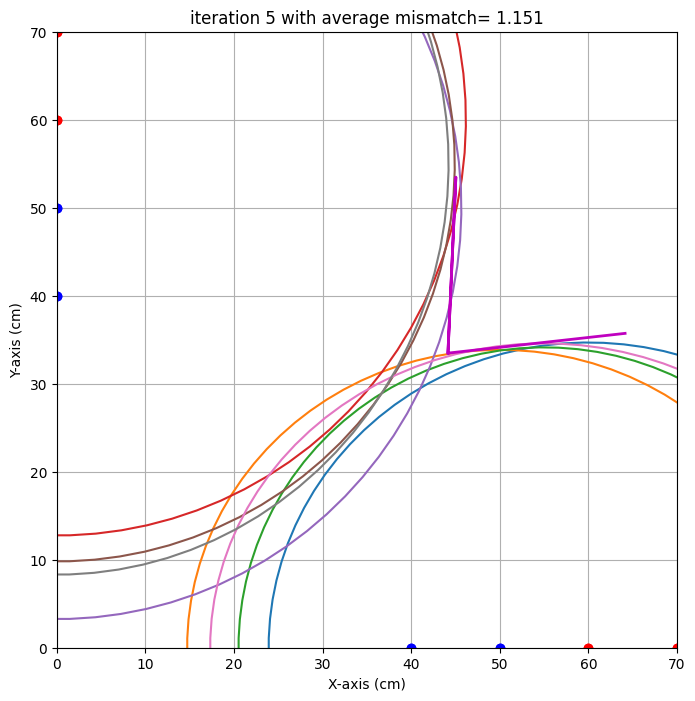

end iteration 5 with average mismatch= 1.151


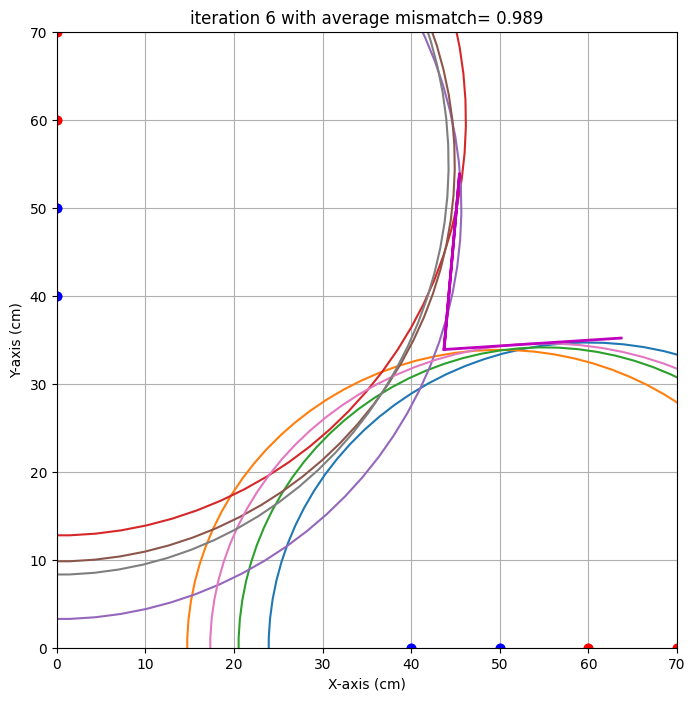

end iteration 6 with average mismatch= 0.989
end iteration 7 with average mismatch= 0.989
end iteration 8 with average mismatch= 0.989
end iteration 9 with average mismatch= 0.989
end iteration 10 with average mismatch= 0.989


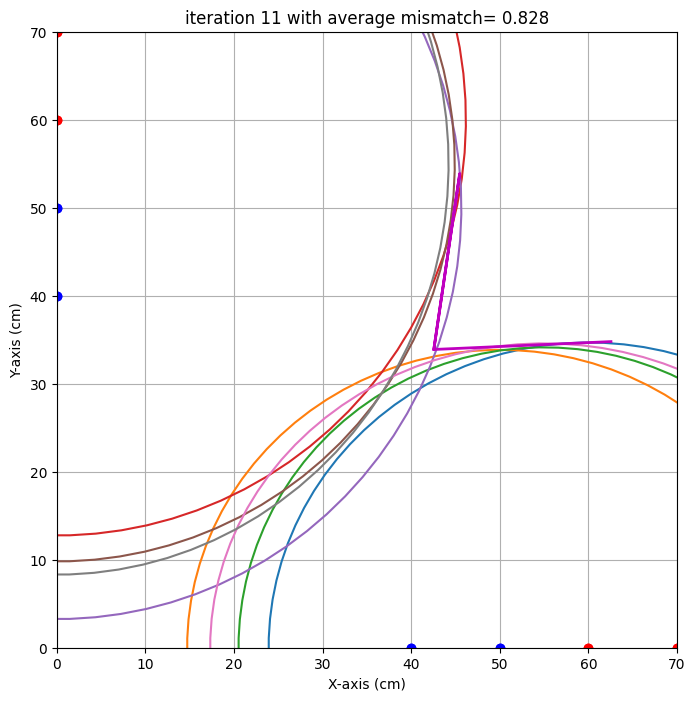

end iteration 11 with average mismatch= 0.828


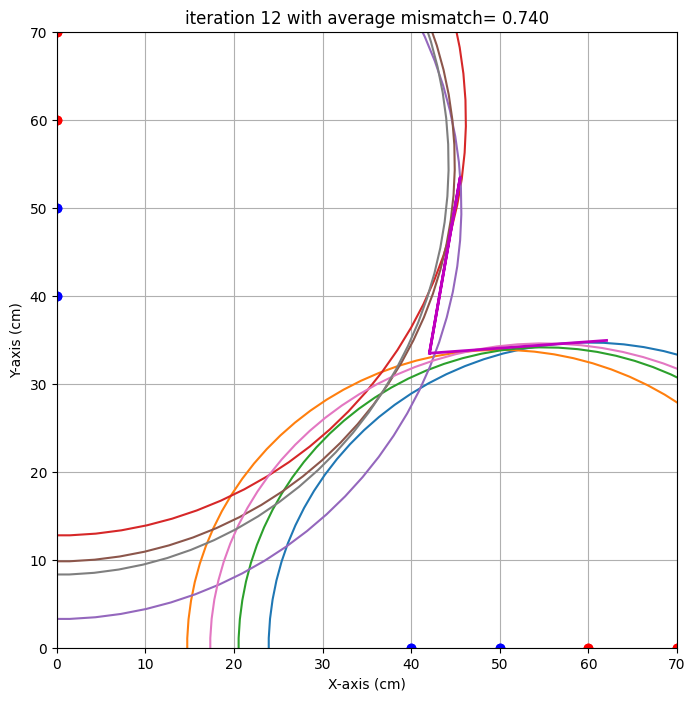

end iteration 12 with average mismatch= 0.740


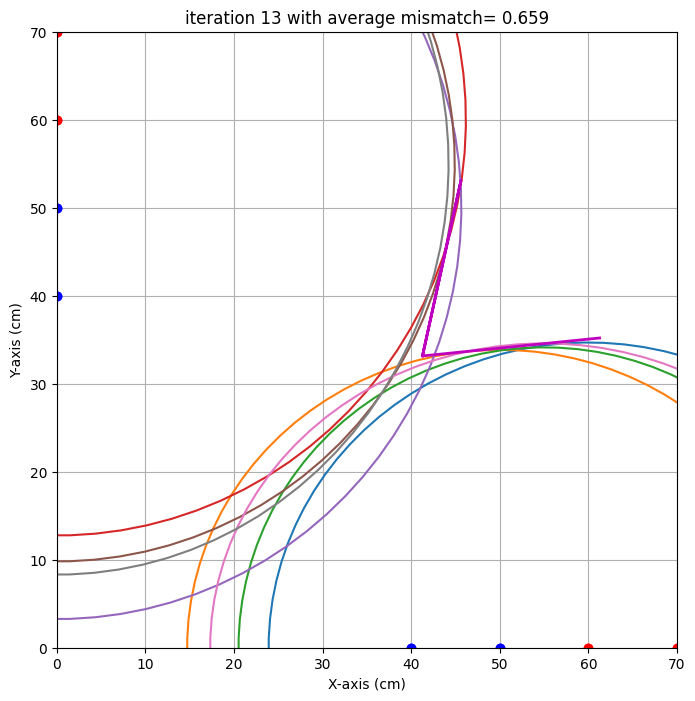

end iteration 13 with average mismatch= 0.659
end iteration 14 with average mismatch= 0.658
end iteration 15 with average mismatch= 0.650
end iteration 16 with average mismatch= 0.649
end iteration 17 with average mismatch= 0.649
end iteration 18 with average mismatch= 0.649
end iteration 19 with average mismatch= 0.649
end iteration 20 with average mismatch= 0.649
end iteration 21 with average mismatch= 0.649
end iteration 22 with average mismatch= 0.649
end iteration 23 with average mismatch= 0.649
end iteration 24 with average mismatch= 0.649
end iteration 25 with average mismatch= 0.649
end iteration 26 with average mismatch= 0.649
end iteration 27 with average mismatch= 0.649
end iteration 28 with average mismatch= 0.649
end iteration 29 with average mismatch= 0.649
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.649
###############################################################

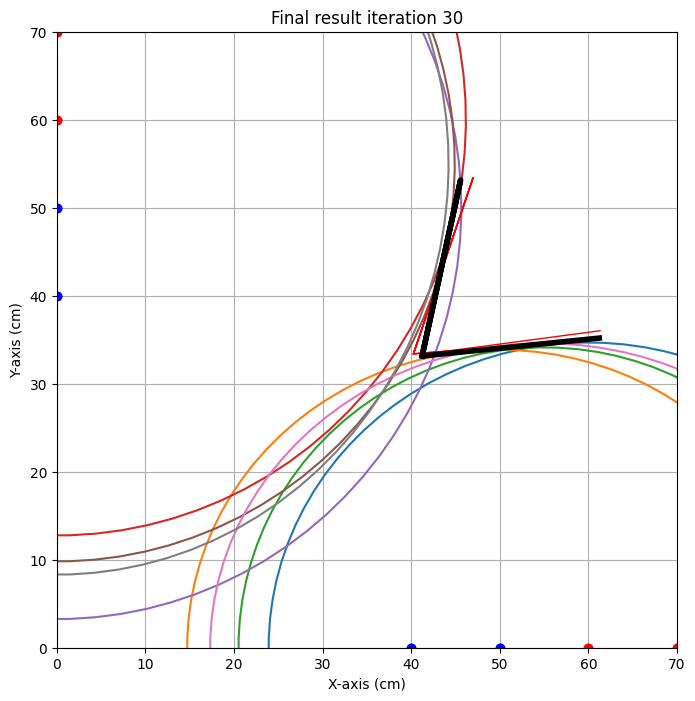

{'alpha': np.float64(5.825385381217316), 'alpha_eps': np.float64(1.7951300068542038), 'beta': np.float64(12.258042133533111), 'beta_eps': np.float64(6.340510322902814), 'x0': np.float64(41.23121700645296), 'x0_eps': np.float64(0.9783677107860527), 'y0': np.float64(33.145477537183396), 'y0_eps': np.float64(0.2520002550613327)}
locatie 1 
x0 target is : 31.0. Gevonden waarde: 33.8 cm met een standaardafwijking van 3.2 cm 
y0 target is : 32.7. Gevonden waarde: 39.4 cm met een standaardafwijking van 1.7 cm 
alpha target is : 38.0. Gevonden waarde: 12.2 graden met een standaardafwijking van 7.1 graad 
beta target is : 7.0. Gevonden waarde: -2.2 graden met een standaardafwijking van 11.0 graad 

locatie 2 
x0 target is : 37.0. Gevonden waarde: 41.2 cm met een standaardafwijking van 1.0 cm 
y0 target is : 32.9. Gevonden waarde: 33.1 cm met een standaardafwijking van 0.3 cm 
alpha target is : 4.0. Gevonden waarde: 5.8 graden met een standaardafwijking van 1.8 graad 
beta target is : 23.0. Gevo

In [14]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 31,
                    'y0': 32.7,
                    'alpha' : 38,
                    'beta' : 7},
           'locatie 2':{'x0': 37 ,
                    'y0': 32.9,
                    'alpha' : 4 ,
                    'beta' : 23 }
            }
           
# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
      [70,0,50,0,88.6],
    #[60,0,40,0,200],
    [70,0,70,0,93.6],
    [60,0,50,0,86.5],
    [65,0,55,0,88.6],
    [70,0,55,0,93.3],  
    [65,0,50,0,88.3],
    [0,70,0,50,75.5],
    [0,60,0,40,69.5],
    [0,60,0,50,66.8],
    [0,70,0,40,74.0],
    [0,65,0,45,66.1],
    #[0,70,0,60,200],
    #[0,70,0,55,200],
    [0,70,0,45,69.8],

   
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
      [70,0,50,0,72.2],
    [60,0,40,0,70.6],
    [60,0,50,0,69.0],
    [0,70,0,50,94.5],  
    [0,60,0,40,93.5],
    [0,60,0,50,90.4],
    [70,0,40,0,75.4],
    [0,70,0,40,93.4],
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

In [13]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':  # zelf aanvullen,
                    'y0':  # zelf aanvullen,
                    'alpha' :  # zelf aanvullen,
                    'beta' :  # zelf aanvullen
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    # zelf aanvullen
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

SyntaxError: invalid syntax (1583240368.py, line 7)

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")